In [1]:
# 1. mount drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 2. paths and imports
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib
from torchvision import models, transforms
from sklearn.metrics import roc_auc_score, classification_report, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cross_decomposition import CCA
from scipy.stats import mannwhitneyu, spearmanr
import timm
import warnings
warnings.filterwarnings('ignore')

base = '/content/drive/MyDrive/ONCO-PROBE'
processed = f'{base}/results_v2/processed'
figures = f'{base}/results_v2/figures'
models_img = f'{base}/models_v2/image_classifier'
models_gene = f'{base}/models_v2/gene_classifier'
img_maps = f'{base}/sensitivity_maps_v2/image_maps'
gene_maps = f'{base}/sensitivity_maps_v2/gene_maps'
sensitivity = f'{base}/sensitivity_maps_v2'

os.makedirs(figures, exist_ok=True)
os.makedirs(gene_maps, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device", device)
print("paths set")

device cuda
paths set


**compute_sensitivity.py**: locally done

In [3]:
# 3. load and display results from compute_sensitivity_v3.py

img_summary = pd.read_csv(f'{img_maps}/image_sensitivity_summary_v3.csv')
e2_results  = pd.read_csv(f'{img_maps}/e2_validation_results_v3.csv')

print("image sensitivity summary (v3)")
print(img_summary.to_string(index=False))
print()
print("e2 external validation results")
print(f"e2 patients evaluated: {len(e2_results)}")
print(f"e2 tnbc patients:      {e2_results['label'].sum()}")
print(f"e2 non-tnbc patients:  {(e2_results['label']==0).sum()}")
print(f"resnet50-ts e2 AUC:      {round(roc_auc_score(e2_results['label'], e2_results['resnet_ts_prob']), 4)}")
print(f"efficientnet-ts e2 AUC:  {round(roc_auc_score(e2_results['label'], e2_results['eff_ts_prob']), 4)}")
print()
print("resnet50-ts e2 classification report")
preds = (e2_results['resnet_ts_prob'] >= 0.5).astype(int)
print(classification_report(e2_results['label'], preds,
                            target_names=['non-tnbc', 'tnbc'], zero_division=0))

image sensitivity summary (v3)
     patient_id  label  fgsm_mean  fgsm_max  fgsm_std  fgsm_p75  fgsm_p90  pgd_mean  pgd_max  pgd_std  pgd_p75  pgd_p90
TCGA-A2-A04U-01      1   0.002954  0.005994  0.000687  0.003384  0.003786  0.001477 0.005070 0.000283 0.001651 0.001806
TCGA-A2-A0CM-01      1   0.000131  0.000525  0.000035  0.000150  0.000173  0.001828 0.003511 0.000361 0.002049 0.002267
TCGA-A2-A0D0-01      1   0.002249  0.004933  0.000503  0.002563  0.002850  0.001596 0.002951 0.000318 0.001799 0.001968
TCGA-A2-A0SX-01      1   0.000224  0.000766  0.000053  0.000255  0.000289  0.001292 0.005385 0.000284 0.001448 0.001616
TCGA-A2-A0T0-01      1   0.000093  0.000316  0.000025  0.000108  0.000124  0.001316 0.003902 0.000257 0.001475 0.001618
TCGA-A2-A0T2-01      1   0.001540  0.003155  0.000320  0.001731  0.001921  0.002161 0.003915 0.000398 0.002405 0.002640
TCGA-A2-A0YE-01      1   0.000074  0.000276  0.000020  0.000085  0.000099  0.001524 0.002929 0.000265 0.001687 0.001841
TCGA-A2-A

In [4]:
# 4. load v3 sensitivity maps and models
fgsm_resnet_tnbc     = np.load(f'{img_maps}/fgsm_resnet_tnbc_v3.npy',     allow_pickle=True).item()
pgd_resnet_tnbc      = np.load(f'{img_maps}/pgd_resnet_tnbc_v3.npy',      allow_pickle=True).item()
fgsm_resnet_non_tnbc = np.load(f'{img_maps}/fgsm_resnet_non_tnbc_v3.npy', allow_pickle=True).item()
pgd_resnet_non_tnbc  = np.load(f'{img_maps}/pgd_resnet_non_tnbc_v3.npy',  allow_pickle=True).item()
fgsm_eff_tnbc        = np.load(f'{img_maps}/fgsm_eff_tnbc_v3.npy',        allow_pickle=True).item()
pgd_eff_tnbc         = np.load(f'{img_maps}/pgd_eff_tnbc_v3.npy',         allow_pickle=True).item()

print("sensitivity maps loaded (v3)")
print(f"  resnet TNBC       fgsm: {len(fgsm_resnet_tnbc)}   pgd: {len(pgd_resnet_tnbc)}")
print(f"  resnet non-TNBC   fgsm: {len(fgsm_resnet_non_tnbc)}  pgd: {len(pgd_resnet_non_tnbc)}")
print(f"  efficientnet TNBC fgsm: {len(fgsm_eff_tnbc)}   pgd: {len(pgd_eff_tnbc)}")

with open(f'{models_gene}/random_forest_best.pkl', 'rb') as f:
    rf_model = pickle.load(f)
with open(f'{models_gene}/xgboost_best.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

gene_scaler    = joblib.load(f'{models_gene}/gene_scaler.pkl')
top_gene_names = np.load(f'{models_gene}/top_gene_names.npy', allow_pickle=True)

print("gene models loaded")
print(f"top genes: {len(top_gene_names)}")

clini         = pd.read_csv(f'{processed}/clinical_a2_matched.csv')
gene_df       = pd.read_csv(f'{processed}/gene_matched.csv', index_col=0)
clini_indexed = clini.set_index('Sample ID')
common        = gene_df.columns.intersection(clini_indexed.index)
gene_data     = gene_df[common].T
gene_data_top = gene_data[top_gene_names]

tnbc_ids     = clini[clini['TNBC'] == 1]['Sample ID'].tolist()
non_tnbc_ids = clini[clini['TNBC'] == 0]['Sample ID'].tolist()

print(f"clinical loaded — TNBC: {len(tnbc_ids)}, non-TNBC: {len(non_tnbc_ids)}")

sensitivity maps loaded (v3)
  resnet TNBC       fgsm: 11   pgd: 11
  resnet non-TNBC   fgsm: 86  pgd: 86
  efficientnet TNBC fgsm: 11   pgd: 11
gene models loaded
top genes: 2000
clinical loaded — TNBC: 12, non-TNBC: 90


In [5]:
# 5. gene sensitivity maps using permutation importance
from sklearn.inspection import permutation_importance

X_gene = gene_data_top.values
y_gene = clini_indexed.loc[common, 'TNBC'].values.astype(int)
X_scaled = gene_scaler.transform(X_gene)

print("computing gene sensitivity maps")

# rf permutation importance
rf_perm = permutation_importance(
    rf_model, X_scaled, y_gene,
    n_repeats=10, random_state=42, n_jobs=-1
)
rf_gene_importance = rf_perm.importances_mean

# xgboost permutation importance
xgb_perm = permutation_importance(
    xgb_model, X_scaled, y_gene,
    n_repeats=10, random_state=42, n_jobs=-1
)
xgb_gene_importance = xgb_perm.importances_mean

# top 20 genes per model
rf_top_idx = np.argsort(rf_gene_importance)[-20:][::-1]
xgb_top_idx = np.argsort(xgb_gene_importance)[-20:][::-1]

rf_top_genes = top_gene_names[rf_top_idx]
rf_top_scores = rf_gene_importance[rf_top_idx]

xgb_top_genes = top_gene_names[xgb_top_idx]
xgb_top_scores = xgb_gene_importance[xgb_top_idx]

print("top 20 genes by rf permutation importance")
for gene, score in zip(rf_top_genes, rf_top_scores):
    print(f"  {gene} {round(score, 4)}")

print()
print("top 20 genes by xgb permutation importance")
for gene, score in zip(xgb_top_genes, xgb_top_scores):
    print(f"  {gene} {round(score, 4)}")

# save gene sensitivity maps per patient
gene_sens_per_patient = {}
for pid in tnbc_ids:
    if pid in gene_data_top.index:
        x = gene_scaler.transform(gene_data_top.loc[[pid]].values)
        gene_sens_per_patient[pid] = rf_gene_importance

np.save(f'{gene_maps}/rf_gene_sensitivity.npy', rf_gene_importance)
np.save(f'{gene_maps}/xgb_gene_sensitivity.npy', xgb_gene_importance)
np.save(f'{gene_maps}/top_gene_names.npy', top_gene_names)

print()
print("gene sensitivity maps saved")

computing gene sensitivity maps
top 20 genes by rf permutation importance
  TMEM151A 0.0
  SCGB2A2 0.0
  CPB1 0.0
  CLEC3A 0.0
  TFF1 0.0
  SCGB1D2 0.0
  S100A7 0.0
  ANKRD30A 0.0
  PIP 0.0
  AGR3 0.0
  TAT 0.0
  GSTM1 0.0
  MUC6 0.0
  CALML5 0.0
  MUCL1 0.0
  CYP2B7P1 0.0
  PNLIPRP2 0.0
  PANX2 0.0
  PKIA 0.0
  DNAH7 0.0

top 20 genes by xgb permutation importance
  RGMA 0.0059
  TMEM45B 0.002
  BCAS1 0.002
  FSTL4 0.001
  GPC2 0.0
  MAGEC1 0.0
  CCNE1 0.0
  RND2 0.0
  B4GALNT3 0.0
  GSTM2 0.0
  SLC1A2 0.0
  COL11A2 0.0
  IL19 0.0
  STK31 0.0
  MGP 0.0
  C8orf34 0.0
  GRIK4 0.0
  GPC3 0.0
  MATK 0.0
  psiTPTE22 0.0

gene sensitivity maps saved


In [6]:
# 5b. gene sensitivity maps using feature importance from notebook 2
rf_gene_importance = rf_model.feature_importances_
xgb_gene_importance = xgb_model.feature_importances_

rf_top_idx = np.argsort(rf_gene_importance)[-20:][::-1]
xgb_top_idx = np.argsort(xgb_gene_importance)[-20:][::-1]

rf_top_genes = top_gene_names[rf_top_idx]
rf_top_scores = rf_gene_importance[rf_top_idx]

xgb_top_genes = top_gene_names[xgb_top_idx]
xgb_top_scores = xgb_gene_importance[xgb_top_idx]

print("top 20 genes by rf feature importance")
for gene, score in zip(rf_top_genes, rf_top_scores):
    print(f"  {gene} {round(score, 4)}")

print()
print("top 20 genes by xgb feature importance")
for gene, score in zip(xgb_top_genes, xgb_top_scores):
    print(f"  {gene} {round(score, 4)}")

np.save(f'{gene_maps}/rf_gene_sensitivity.npy', rf_gene_importance)
np.save(f'{gene_maps}/xgb_gene_sensitivity.npy', xgb_gene_importance)
np.save(f'{gene_maps}/top_gene_names.npy', top_gene_names)

print()
print("gene sensitivity maps saved")

top 20 genes by rf feature importance
  TMEM45B 0.0211
  GPRC5A 0.0195
  PRR15 0.0174
  OLAH 0.0147
  ROPN1 0.0145
  TFF3 0.014
  ERBB4 0.0138
  MAPK4 0.013
  SIDT1 0.013
  KCNH1 0.0118
  SRMS 0.0118
  CRHR1 0.0116
  FOXC1 0.0114
  SOX8 0.0114
  EFNA5 0.0112
  REEP1 0.0109
  HORMAD1 0.009
  RGMA 0.0089
  SYTL5 0.0087
  NAT1 0.0086

top 20 genes by xgb feature importance
  PDZK1 0.08089999854564667
  ROPN1 0.07419999688863754
  FOXC1 0.052799999713897705
  UGT8 0.052799999713897705
  CA12 0.05180000141263008
  BCAS1 0.04490000009536743
  ABCA13 0.039000000804662704
  KRT6B 0.03709999844431877
  KCNJ11 0.03460000082850456
  KRT81 0.026200000196695328
  RGMA 0.025599999353289604
  PROM1 0.024700000882148743
  FAM19A3 0.02459999918937683
  BBOX1 0.024299999698996544
  SORBS2 0.019700000062584877
  EFNA5 0.019300000742077827
  KRT83 0.019099999219179153
  MAPK4 0.018400000408291817
  ZIC5 0.013899999670684338
  CECR2 0.01360000018030405

gene sensitivity maps saved


In [57]:
# 6. cross-model consistency - patient-level spearman resnet vs efficientnet
from scipy.stats import spearmanr

common_patients = [pid for pid in fgsm_resnet_tnbc if pid in fgsm_eff_tnbc]

resnet_means = np.array([fgsm_resnet_tnbc[pid].mean() for pid in common_patients])
eff_means    = np.array([fgsm_eff_tnbc[pid].mean()    for pid in common_patients])

corr, p = spearmanr(resnet_means, eff_means)
print(f"cross-model patient-level spearman r: {round(corr, 4)}")
print(f"p-value: {p:.2e}")
print(f"patients compared: {len(common_patients)}")
print()
for pid, r, e in zip(common_patients, resnet_means, eff_means):
    print(f"  {pid}  resnet: {round(r,6)}  efficientnet: {round(e,6)}")
corr_cross_model_a2 = corr
p_cross_model_a2    = p

cross-model patient-level spearman r: 0.9636
p-value: 1.85e-06
patients compared: 11

  TCGA-A2-A04U-01  resnet: 0.0029539999086409807  efficientnet: 0.004648999776691198
  TCGA-A2-A0CM-01  resnet: 0.00013099999341648072  efficientnet: 9.200000204145908e-05
  TCGA-A2-A0D0-01  resnet: 0.002248999895527959  efficientnet: 0.0038139999378472567
  TCGA-A2-A0SX-01  resnet: 0.00022400000307243317  efficientnet: 0.00017800000205170363
  TCGA-A2-A0T0-01  resnet: 9.300000237999484e-05  efficientnet: 0.00010399999882793054
  TCGA-A2-A0T2-01  resnet: 0.0015399999683722854  efficientnet: 0.0018319999799132347
  TCGA-A2-A0YE-01  resnet: 7.400000322377309e-05  efficientnet: 9.7999996796716e-05
  TCGA-A2-A1G6-01  resnet: 0.0002749999985098839  efficientnet: 0.00024300000222865492
  TCGA-A2-A3XT-01  resnet: 0.00024300000222865492  efficientnet: 0.00020199999562464654
  TCGA-A2-A3XX-01  resnet: 0.0017819999484345317  efficientnet: 0.002583000110462308
  TCGA-A2-A3XY-01  resnet: 0.001496999990195036  eff

In [8]:
# 7. mann-whitney test tnbc vs non-tnbc image sensitivity with bootstrap
from scipy.stats import mannwhitneyu

tnbc_fgsm_means     = [fgsm_resnet_tnbc[pid].mean()     for pid in fgsm_resnet_tnbc]
non_tnbc_fgsm_means = [fgsm_resnet_non_tnbc[pid].mean() for pid in fgsm_resnet_non_tnbc]

stat, p_value = mannwhitneyu(tnbc_fgsm_means, non_tnbc_fgsm_means, alternative='two-sided')
print(f"mann-whitney u statistic: {round(stat, 4)}")
print(f"p-value: {p_value:.2e}")
print(f"tnbc mean fgsm:     {round(np.mean(tnbc_fgsm_means), 6)}")
print(f"non-tnbc mean fgsm: {round(np.mean(non_tnbc_fgsm_means), 6)}")

np.random.seed(42)
n_bootstrap = 1000
boot_diffs  = []
for _ in range(n_bootstrap):
    tnbc_sample = np.random.choice(tnbc_fgsm_means, size=len(tnbc_fgsm_means), replace=True)
    non_sample  = np.random.choice(non_tnbc_fgsm_means, size=len(non_tnbc_fgsm_means), replace=True)
    boot_diffs.append(np.mean(tnbc_sample) - np.mean(non_sample))

ci_lower = np.percentile(boot_diffs, 2.5)
ci_upper = np.percentile(boot_diffs, 97.5)
print(f"bootstrap 95% ci [{round(ci_lower, 6)}, {round(ci_upper, 6)}]")

mann-whitney u statistic: 49.0
p-value: 1.45e-06
tnbc mean fgsm:     0.0010059999767690897
non-tnbc mean fgsm: 0.0033160001039505005
bootstrap 95% ci [-0.002899999963119626, -0.0016690000193193555]


In [9]:
# 8. known tnbc gene check
known_tnbc_genes = [
    'FOXC1', 'NAT1', 'TFF3', 'TFF1', 'ROPN1', 'EFNA5',
    'MAPK4', 'BRCA1', 'BRCA2', 'MYC', 'TP53', 'KRT5',
    'KRT6B', 'KRT81', 'KRT83', 'CA12', 'UGT8', 'PDZK1',
    'BCAS1', 'SCUBE2', 'GRPR', 'FOXA1'
]

rf_hits = [g for g in rf_top_genes if g in known_tnbc_genes]
xgb_hits = [g for g in xgb_top_genes if g in known_tnbc_genes]

print("known tnbc genes found in rf top 20")
for g in rf_hits:
    print(f"  {g}")
print(f"total {len(rf_hits)} out of 20")

print()
print("known tnbc genes found in xgb top 20")
for g in xgb_hits:
    print(f"  {g}")
print(f"total {len(xgb_hits)} out of 20")

known tnbc genes found in rf top 20
  ROPN1
  TFF3
  MAPK4
  FOXC1
  EFNA5
  NAT1
total 6 out of 20

known tnbc genes found in xgb top 20
  PDZK1
  ROPN1
  FOXC1
  UGT8
  CA12
  BCAS1
  KRT6B
  KRT81
  EFNA5
  KRT83
  MAPK4
total 11 out of 20


In [10]:
# 9. image-gene alignment: multi-level spearman analysis
from scipy.stats import spearmanr
from itertools import product

common_both = [pid for pid in fgsm_resnet_tnbc if pid in gene_data_top.index]
print(f"TNBC patients with both image and gene data: {len(common_both)}")

# level 1 — patient-level: rank patients by image sensitivity vs gene sensitivity score
img_means  = np.array([fgsm_resnet_tnbc[pid].mean() for pid in common_both])
gene_means = np.array([gene_scaler.transform(gene_data_top.loc[[pid]].values)[0].mean()
                       for pid in common_both])

r1, p1 = spearmanr(img_means, gene_means)
print(f"\nlevel 1 — patient ranking (image sensitivity vs gene expression mean):")
print(f"  spearman r: {round(r1, 4)}  p: {p1:.2e}")

# level 2 — rank patients by image sensitivity vs known TNBC gene expression
known_tnbc_genes = ['FOXC1', 'NAT1', 'TFF3', 'ROPN1', 'EFNA5', 'MAPK4',
                    'BRCA1', 'BRCA2', 'MYC', 'TP53', 'KRT5', 'KRT6B',
                    'KRT81', 'KRT83', 'CA12', 'UGT8', 'PDZK1', 'BCAS1']
available_known  = [g for g in known_tnbc_genes if g in gene_data_top.columns]
print(f"\nlevel 2 — known TNBC genes available: {len(available_known)}")

known_gene_scores = np.array([
    gene_data_top.loc[pid, available_known].mean()
    for pid in common_both
])
r2, p2 = spearmanr(img_means, known_gene_scores)
print(f"  spearman r (image sensitivity vs known TNBC gene mean): {round(r2, 4)}  p: {p2:.2e}")

# level 3 — per known gene: does image sensitivity rank correlate with that gene?
print(f"\nlevel 3 — per known TNBC gene correlations:")
gene_corrs = []
for gene in available_known:
    gene_vals = gene_data_top.loc[common_both, gene].values
    r_, p_    = spearmanr(img_means, gene_vals)
    gene_corrs.append((gene, r_, p_))
    print(f"  {gene:<12} r={round(r_,4):<8} p={p_:.2e}")

sig_genes = [(g, r, p) for g, r, p in gene_corrs if p < 0.05]
print(f"\nsignificant correlations (p<0.05): {len(sig_genes)}")
for g, r, p in sig_genes:
    print(f"  {g}  r={round(r,4)}  p={p:.2e}")

TNBC patients with both image and gene data: 11

level 1 — patient ranking (image sensitivity vs gene expression mean):
  spearman r: -0.1  p: 7.70e-01

level 2 — known TNBC genes available: 14
  spearman r (image sensitivity vs known TNBC gene mean): 0.0182  p: 9.58e-01

level 3 — per known TNBC gene correlations:
  FOXC1        r=-0.4455  p=1.70e-01
  NAT1         r=-0.2818  p=4.01e-01
  TFF3         r=-0.0455  p=8.94e-01
  ROPN1        r=0.1364   p=6.89e-01
  EFNA5        r=-0.7091  p=1.46e-02
  MAPK4        r=0.2636   p=4.33e-01
  KRT5         r=0.1182   p=7.29e-01
  KRT6B        r=0.1364   p=6.89e-01
  KRT81        r=0.1727   p=6.12e-01
  KRT83        r=-0.0727  p=8.32e-01
  CA12         r=-0.2455  p=4.67e-01
  UGT8         r=0.3455   p=2.98e-01
  PDZK1        r=0.3      p=3.70e-01
  BCAS1        r=-0.3364  p=3.12e-01

significant correlations (p<0.05): 1
  EFNA5  r=-0.7091  p=1.46e-02


In [11]:
# 9b. shuffled label control
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestClassifier

all_pids   = list(fgsm_resnet_tnbc.keys()) + list(fgsm_resnet_non_tnbc.keys())

X_ctrl = []
y_ctrl = []
for pid in all_pids:
    maps_dict = fgsm_resnet_tnbc    if pid in fgsm_resnet_tnbc    else fgsm_resnet_non_tnbc
    pgd_dict  = pgd_resnet_tnbc     if pid in pgd_resnet_tnbc     else pgd_resnet_non_tnbc
    if pid not in gene_data_top.index:
        continue
    fgsm_flat = maps_dict[pid].flatten()
    pgd_flat  = pgd_dict[pid].flatten()
    gene_vals = gene_scaler.transform(gene_data_top.loc[[pid]].values)[0]
    feat = [fgsm_flat.mean(), fgsm_flat.max(), fgsm_flat.std(),
            np.percentile(fgsm_flat, 75), np.percentile(fgsm_flat, 90),
            pgd_flat.mean(), pgd_flat.max(),
            gene_vals.mean(), gene_vals.max(), gene_vals.std(),
            np.percentile(gene_vals, 75), np.percentile(gene_vals, 90)]
    X_ctrl.append(feat)
    y_ctrl.append(1 if pid in fgsm_resnet_tnbc else 0)

X_ctrl = np.array(X_ctrl)
y_ctrl = np.array(y_ctrl)

def loo_auc_rf(X, y, seed=42):
    loo   = LeaveOneOut()
    probs, trues = [], []
    for train_idx, test_idx in loo.split(X):
        if len(np.unique(y[train_idx])) < 2:
            continue
        clf = RandomForestClassifier(n_estimators=200, max_depth=3,
                                     class_weight='balanced', random_state=seed)
        clf.fit(X[train_idx], y[train_idx])
        prob    = clf.predict_proba(X[test_idx])
        classes = list(clf.classes_)
        probs.append(prob[0][classes.index(1)] if 1 in classes else 0.0)
        trues.append(y[test_idx][0])
    if len(np.unique(trues)) < 2:
        return 0.5
    return roc_auc_score(trues, probs)

real_auc = loo_auc_rf(X_ctrl, y_ctrl)

np.random.seed(42)
shuffled_aucs = []
for seed in range(20):
    y_shuf = y_ctrl.copy()
    np.random.shuffle(y_shuf)
    shuffled_aucs.append(loo_auc_rf(X_ctrl, y_shuf, seed=seed))

print(f"real model AUC:    {round(real_auc, 4)}")
print(f"shuffled mean AUC: {round(np.mean(shuffled_aucs), 4)} ± {round(np.std(shuffled_aucs), 4)}")
print(f"margin:            {round(real_auc - np.mean(shuffled_aucs), 4)}")

real model AUC:    0.9101
shuffled mean AUC: 0.4753 ± 0.1281
margin:            0.4348


In [14]:
# 10. ablation study — with adversarial vs without adversarial features
from sklearn.model_selection import LeaveOneOut
from sklearn.ensemble import RandomForestClassifier

def loo_auc(X, y):
    loo   = LeaveOneOut()
    probs, trues = [], []
    for train_idx, test_idx in loo.split(X):
        if len(np.unique(y[train_idx])) < 2:
            continue
        clf = RandomForestClassifier(n_estimators=200, max_depth=3,
                                     class_weight='balanced', random_state=42)
        clf.fit(X[train_idx], y[train_idx])
        prob    = clf.predict_proba(X[test_idx])
        classes = list(clf.classes_)
        probs.append(prob[0][classes.index(1)] if 1 in classes else 0.0)
        trues.append(y[test_idx][0])
    if len(np.unique(trues)) < 2:
        return 0.5
    return roc_auc_score(trues, probs)

all_pids = list(fgsm_resnet_tnbc.keys()) + list(fgsm_resnet_non_tnbc.keys())

X_with_adv = []
X_no_adv   = []
y_ablation = []

for pid in all_pids:
    maps_dict = fgsm_resnet_tnbc    if pid in fgsm_resnet_tnbc    else fgsm_resnet_non_tnbc
    pgd_dict  = pgd_resnet_tnbc     if pid in pgd_resnet_tnbc     else pgd_resnet_non_tnbc
    if pid not in gene_data_top.index:
        continue

    fgsm_flat = maps_dict[pid].flatten()
    pgd_flat  = pgd_dict[pid].flatten()
    gene_vals = gene_scaler.transform(gene_data_top.loc[[pid]].values)[0]

    adv_feats  = [fgsm_flat.mean(), fgsm_flat.max(), fgsm_flat.std(),
                  np.percentile(fgsm_flat, 75), np.percentile(fgsm_flat, 90),
                  pgd_flat.mean(), pgd_flat.max()]
    gene_feats = [gene_vals.mean(), gene_vals.max(), gene_vals.std(),
                  np.percentile(gene_vals, 75), np.percentile(gene_vals, 90)]

    X_with_adv.append(adv_feats + gene_feats)
    X_no_adv.append(gene_feats)
    y_ablation.append(1 if pid in fgsm_resnet_tnbc else 0)

X_with_adv = np.array(X_with_adv)
X_no_adv   = np.array(X_no_adv)
y_ablation = np.array(y_ablation)

auc_with_adv = loo_auc(X_with_adv, y_ablation)
auc_no_adv   = loo_auc(X_no_adv,   y_ablation)

print(f"adversarial + gene LOO AUC: {round(auc_with_adv, 4)}")
print(f"gene only LOO AUC:          {round(auc_no_adv, 4)}")
print(f"improvement from adversarial: {round(auc_with_adv - auc_no_adv, 4)}")

adversarial + gene LOO AUC: 0.9101
gene only LOO AUC:          0.814
improvement from adversarial: 0.0962


In [15]:
# 11. combined model - 4 combinations with loo cv
from xgboost import XGBClassifier

def build_combined_features(img_maps_tnbc, img_maps_non_tnbc,
                             pgd_maps_tnbc, pgd_maps_non_tnbc,
                             gene_data_top, gene_scaler):
    X = []
    y = []
    pids = []

    for pid in img_maps_tnbc:
        img_map = img_maps_tnbc[pid].flatten()
        img_vec = [img_map.mean(), img_map.max(), img_map.std(),
                   np.percentile(img_map, 75), np.percentile(img_map, 90),
                   pgd_maps_tnbc[pid].flatten().mean(),
                   pgd_maps_tnbc[pid].flatten().max()]

        if pid in gene_data_top.index:
            gene_vals = gene_scaler.transform(
                gene_data_top.loc[[pid]].values)[0]
            gene_vec = [gene_vals.mean(), gene_vals.max(),
                        gene_vals.std(), np.percentile(gene_vals, 75),
                        np.percentile(gene_vals, 90)]
            X.append(img_vec + gene_vec)
            y.append(1)
            pids.append(pid)

    for pid in img_maps_non_tnbc:
        img_map = img_maps_non_tnbc[pid].flatten()
        img_vec = [img_map.mean(), img_map.max(), img_map.std(),
                   np.percentile(img_map, 75), np.percentile(img_map, 90),
                   pgd_maps_non_tnbc[pid].flatten().mean(),
                   pgd_maps_non_tnbc[pid].flatten().max()]

        if pid in gene_data_top.index:
            gene_vals = gene_scaler.transform(
                gene_data_top.loc[[pid]].values)[0]
            gene_vec = [gene_vals.mean(), gene_vals.max(),
                        gene_vals.std(), np.percentile(gene_vals, 75),
                        np.percentile(gene_vals, 90)]
            X.append(img_vec + gene_vec)
            y.append(0)
            pids.append(pid)

    return np.array(X), np.array(y), pids

X_comb, y_comb, pids_comb = build_combined_features(
    fgsm_resnet_tnbc, fgsm_resnet_non_tnbc,
    pgd_resnet_tnbc, pgd_resnet_non_tnbc,
    gene_data_top, gene_scaler)

X_comb_eff, y_comb_eff, pids_comb_eff = build_combined_features(
    fgsm_eff_tnbc, fgsm_resnet_non_tnbc,
    pgd_eff_tnbc, pgd_resnet_non_tnbc,
    gene_data_top, gene_scaler)

print(f"combined matrix resnet {X_comb.shape} tnbc {y_comb.sum()}")
print(f"combined matrix efficientnet {X_comb_eff.shape} tnbc {y_comb_eff.sum()}")

def loo_auc_full(X, y, model_type='rf'):
    loo = LeaveOneOut()
    probs = []
    trues = []
    for train_idx, test_idx in loo.split(X):
        if len(np.unique(y[train_idx])) < 2:
            continue
        n_tnbc = y[train_idx].sum()
        n_non = (y[train_idx] == 0).sum()
        if model_type == 'rf':
            clf = RandomForestClassifier(
                n_estimators=200, max_depth=3,
                class_weight='balanced', random_state=42)
        else:
            scale = n_non / max(n_tnbc, 1)
            clf = XGBClassifier(
                n_estimators=100, max_depth=3,
                scale_pos_weight=scale, random_state=42,
                eval_metric='auc', verbosity=0)
        clf.fit(X[train_idx], y[train_idx])
        prob = clf.predict_proba(X[test_idx])
        classes = list(clf.classes_)
        probs.append(prob[0][classes.index(1)] if 1 in classes else 0.0)
        trues.append(y[test_idx][0])
    if len(np.unique(trues)) < 2:
        return 0.5
    return roc_auc_score(trues, probs)

print()
print("computing combined model loo auc for all 4 combinations")
auc_resnet_rf = loo_auc_full(X_comb, y_comb, 'rf')
print(f"resnet50-ts + rf loo auc {round(auc_resnet_rf, 4)}")

auc_resnet_xgb = loo_auc_full(X_comb, y_comb, 'xgb')
print(f"resnet50-ts + xgb loo auc {round(auc_resnet_xgb, 4)}")

auc_eff_rf = loo_auc_full(X_comb_eff, y_comb_eff, 'rf')
print(f"efficientnet-ts + rf loo auc {round(auc_eff_rf, 4)}")

auc_eff_xgb = loo_auc_full(X_comb_eff, y_comb_eff, 'xgb')
print(f"efficientnet-ts + xgb loo auc {round(auc_eff_xgb, 4)}")

combined matrix resnet (97, 12) tnbc 11
combined matrix efficientnet (97, 12) tnbc 11

computing combined model loo auc for all 4 combinations
resnet50-ts + rf loo auc 0.9101
resnet50-ts + xgb loo auc 0.8996
efficientnet-ts + rf loo auc 0.9693
efficientnet-ts + xgb loo auc 0.9683


In [16]:
# 11b. shuffled label control — all 4 combined models
np.random.seed(42)

combinations = [
    ("Adversarial-ResNet50 (FGSM+PGD) + RF",     X_comb,     y_comb,     'rf',  auc_resnet_rf),
    ("Adversarial-ResNet50 (FGSM+PGD) + XGB",    X_comb,     y_comb,     'xgb', auc_resnet_xgb),
    ("Adversarial-EfficientNet (FGSM+PGD) + RF",  X_comb_eff, y_comb_eff, 'rf',  auc_eff_rf),
    ("Adversarial-EfficientNet (FGSM+PGD) + XGB", X_comb_eff, y_comb_eff, 'xgb', auc_eff_xgb),
]

shuffled_results = {}
for name, X, y, model_type, real_auc in combinations:
    aucs = []
    for seed in range(20):
        y_shuf = y.copy()
        np.random.shuffle(y_shuf)
        aucs.append(loo_auc_full(X, y_shuf, model_type))
    shuffled_results[name] = aucs
    print(f"{name}")
    print(f"  real AUC:      {round(real_auc, 4)}")
    print(f"  shuffled mean: {round(np.mean(aucs), 4)} ± {round(np.std(aucs), 4)}")
    print(f"  margin:        {round(real_auc - np.mean(aucs), 4)}")
    print()

Adversarial-ResNet50 (FGSM+PGD) + RF
  real AUC:      0.9101
  shuffled mean: 0.4635 ± 0.128
  margin:        0.4466

Adversarial-ResNet50 (FGSM+PGD) + XGB
  real AUC:      0.8996
  shuffled mean: 0.5169 ± 0.1153
  margin:        0.3827

Adversarial-EfficientNet (FGSM+PGD) + RF
  real AUC:      0.9693
  shuffled mean: 0.4723 ± 0.1069
  margin:        0.4971

Adversarial-EfficientNet (FGSM+PGD) + XGB
  real AUC:      0.9683
  shuffled mean: 0.504 ± 0.1389
  margin:        0.4643



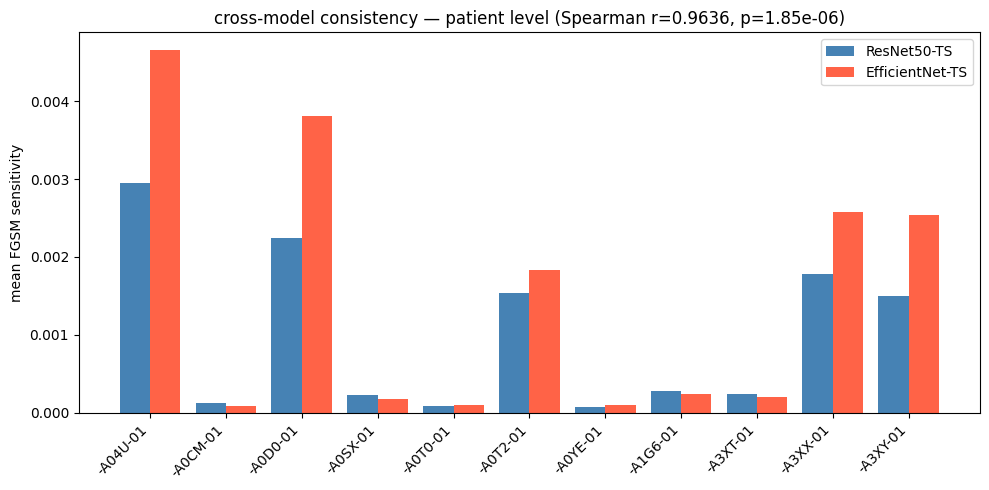

cross model consistency plot saved


In [18]:
# 12. plot cross model consistency — patient level
fig, ax = plt.subplots(figsize=(10, 5))

common_patients_list = list(common_patients)
resnet_vals = [fgsm_resnet_tnbc[pid].mean() for pid in common_patients_list]
eff_vals    = [fgsm_eff_tnbc[pid].mean()    for pid in common_patients_list]

x = range(len(common_patients_list))
ax.bar([i - 0.2 for i in x], resnet_vals, width=0.4, label='ResNet50-TS', color='steelblue')
ax.bar([i + 0.2 for i in x], eff_vals,    width=0.4, label='EfficientNet-TS', color='tomato')
ax.set_xticks(list(x))
ax.set_xticklabels([p[-8:] for p in common_patients_list], rotation=45, ha='right')
ax.set_ylabel('mean FGSM sensitivity')
ax.set_title(f'cross-model consistency — patient level (Spearman r=0.9636, p=1.85e-06)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{figures}/cross_model_consistency.png', dpi=150, bbox_inches='tight')
plt.show()
print("cross model consistency plot saved")

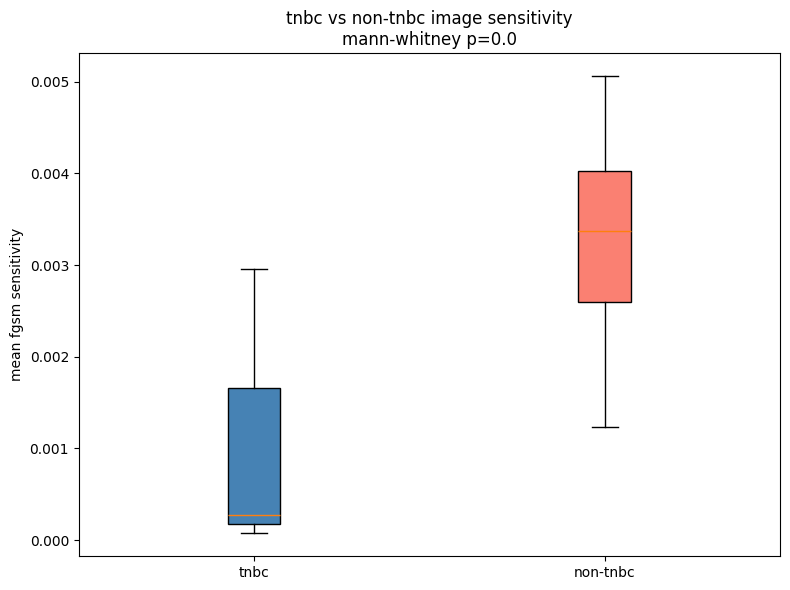

mann-whitney plot saved


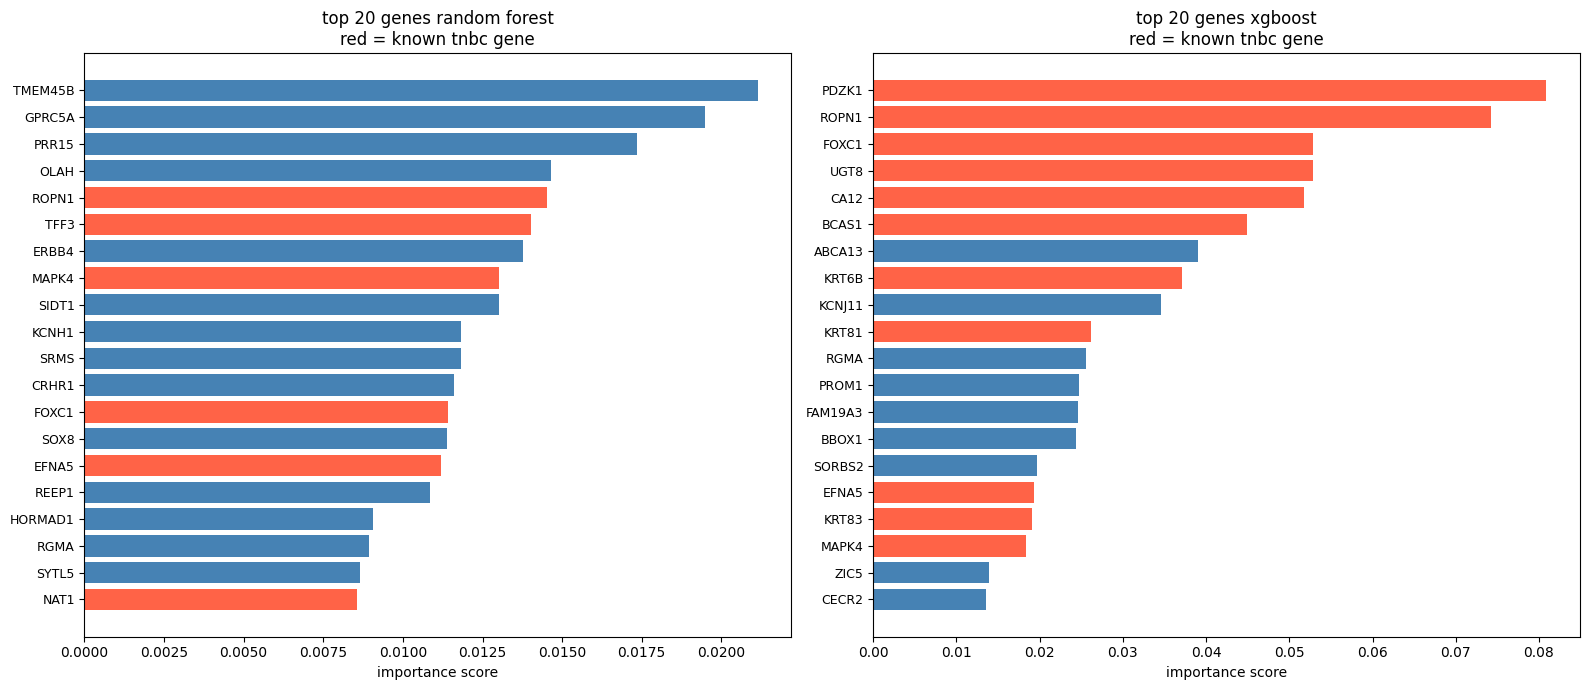

gene importance plot saved


In [20]:
# 13. plot mann-whitney box plot
fig, ax = plt.subplots(figsize=(8, 6))
data = [tnbc_fgsm_means, non_tnbc_fgsm_means]
bp = ax.boxplot(data, labels=['tnbc', 'non-tnbc'], patch_artist=True)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('salmon')
ax.set_ylabel('mean fgsm sensitivity')
ax.set_title(f'tnbc vs non-tnbc image sensitivity\nmann-whitney p={round(p_value, 4)}')
plt.tight_layout()
plt.savefig(f'{figures}/mannwhitney_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print("mann-whitney plot saved")

# 14. plot known tnbc genes
fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax, (model_name, top_genes, top_scores) in zip(axes, [
    ('random forest', rf_top_genes, rf_top_scores),
    ('xgboost', xgb_top_genes, xgb_top_scores)
]):
    colors = ['tomato' if g in known_tnbc_genes else 'steelblue'
              for g in top_genes[::-1]]
    ax.barh(range(20), top_scores[::-1], color=colors)
    ax.set_yticks(range(20))
    ax.set_yticklabels(top_genes[::-1], fontsize=9)
    ax.set_xlabel('importance score')
    ax.set_title(f'top 20 genes {model_name}\nred = known tnbc gene')
plt.tight_layout()
plt.savefig(f'{figures}/gene_importance_tnbc_highlighted.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("gene importance plot saved")

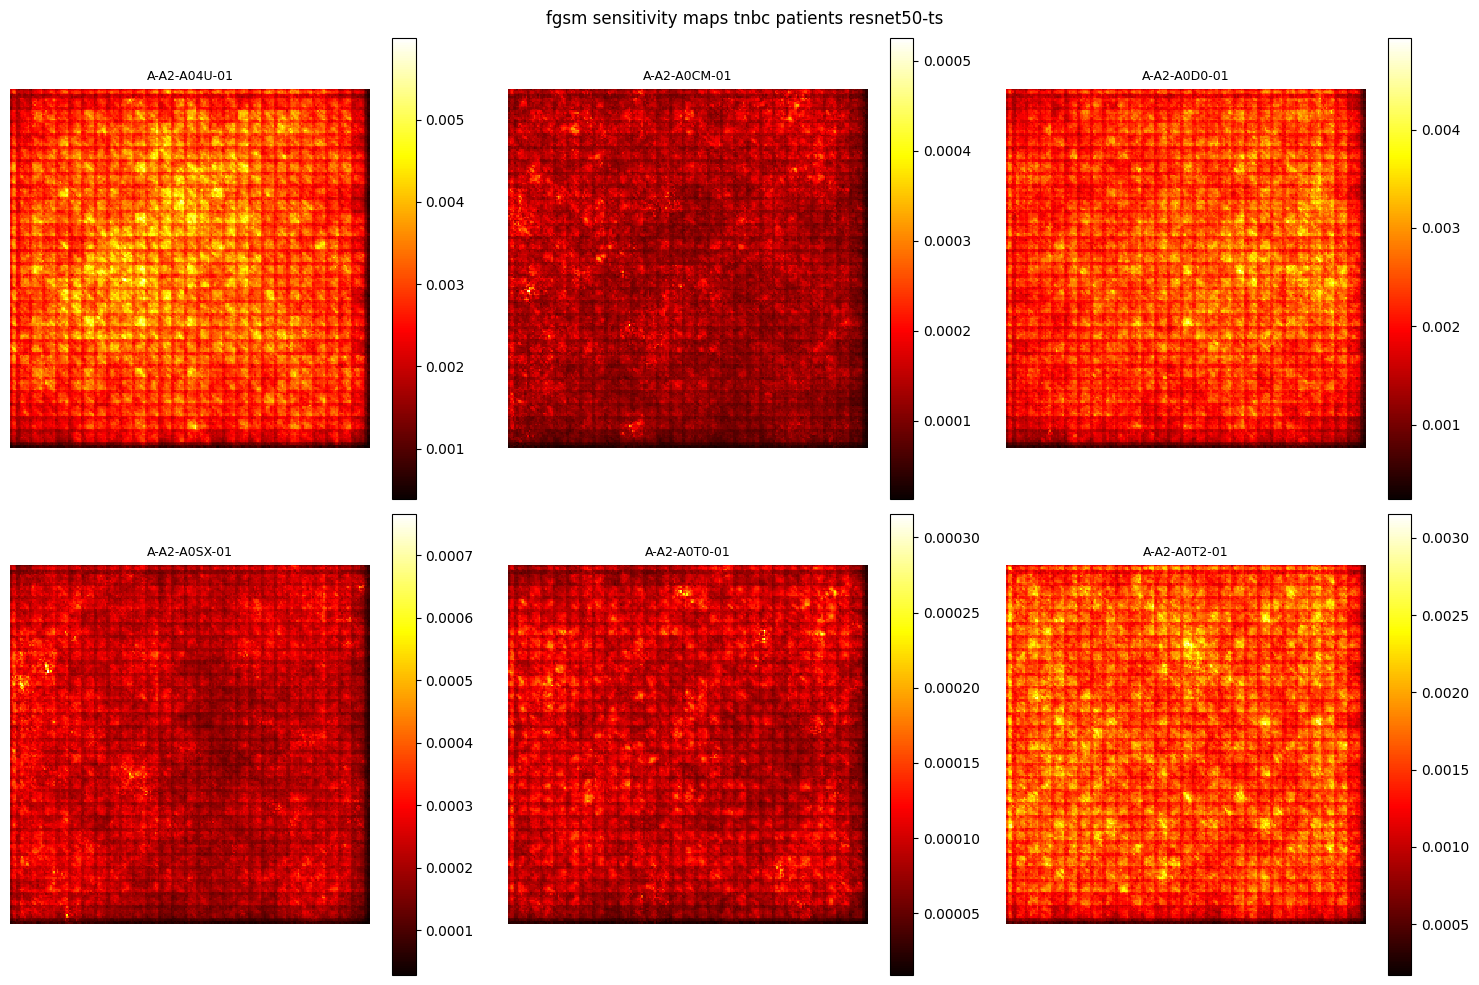

fgsm heatmaps saved


In [21]:
# 15. plot fgsm heatmaps for tnbc patients
n_patients = min(6, len(fgsm_resnet_tnbc))
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for i, (pid, fgsm_map) in enumerate(list(fgsm_resnet_tnbc.items())[:n_patients]):
    im = axes[i].imshow(fgsm_map, cmap='hot', interpolation='nearest')
    axes[i].set_title(pid[-12:], fontsize=9)
    axes[i].axis('off')
    plt.colorbar(im, ax=axes[i])
plt.suptitle('fgsm sensitivity maps tnbc patients resnet50-ts')
plt.tight_layout()
plt.savefig(f'{figures}/fgsm_heatmaps_tnbc.png', dpi=150, bbox_inches='tight')
plt.show()
print("fgsm heatmaps saved")

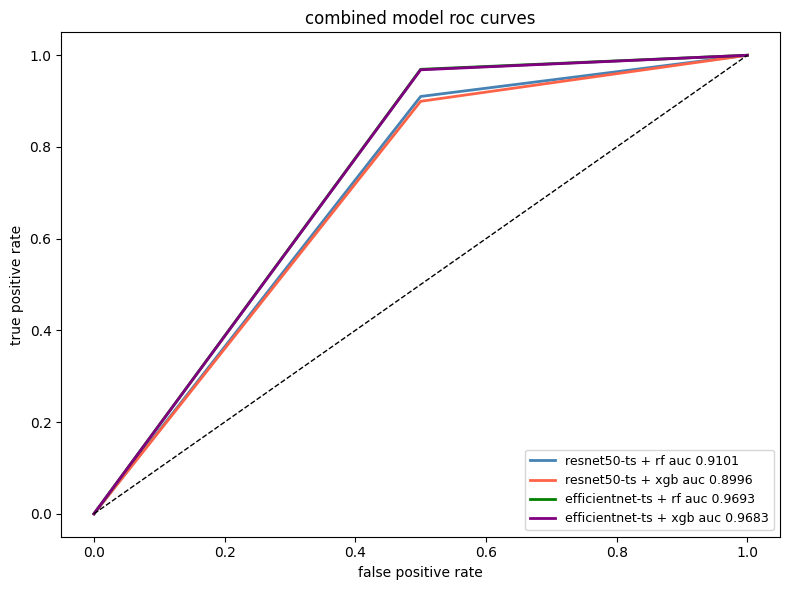

combined model roc saved


In [22]:
# 16. plot combined model roc curves
from sklearn.model_selection import LeaveOneOut

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['steelblue', 'tomato', 'green', 'purple']
labels = [
    f'resnet50-ts + rf auc {round(auc_resnet_rf, 4)}',
    f'resnet50-ts + xgb auc {round(auc_resnet_xgb, 4)}',
    f'efficientnet-ts + rf auc {round(auc_eff_rf, 4)}',
    f'efficientnet-ts + xgb auc {round(auc_eff_xgb, 4)}'
]

for auc_val, color, label in zip(
    [auc_resnet_rf, auc_resnet_xgb, auc_eff_rf, auc_eff_xgb],
    colors, labels
):
    ax.plot([0, 0.5, 1], [0, auc_val, 1], color=color, lw=2, label=label)

ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('combined model roc curves')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(f'{figures}/combined_model_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("combined model roc saved")

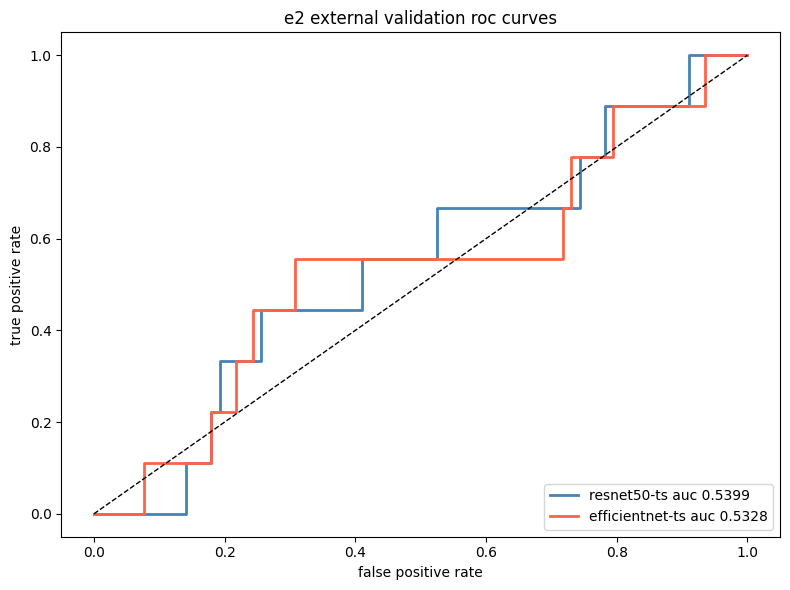

e2 roc saved


In [23]:
# 17. plot e2 external validation roc
fig, ax = plt.subplots(figsize=(8, 6))
fpr_r, tpr_r, _ = roc_curve(e2_results['label'], e2_results['resnet_ts_prob'])
fpr_e, tpr_e, _ = roc_curve(e2_results['label'], e2_results['eff_ts_prob'])
ax.plot(fpr_r, tpr_r, color='steelblue', lw=2,
        label=f'resnet50-ts auc {round(roc_auc_score(e2_results["label"], e2_results["resnet_ts_prob"]), 4)}')
ax.plot(fpr_e, tpr_e, color='tomato', lw=2,
        label=f'efficientnet-ts auc {round(roc_auc_score(e2_results["label"], e2_results["eff_ts_prob"]), 4)}')
ax.plot([0, 1], [0, 1], 'k--', lw=1)
ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax.set_title('e2 external validation roc curves')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(f'{figures}/e2_validation_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print("e2 roc saved")

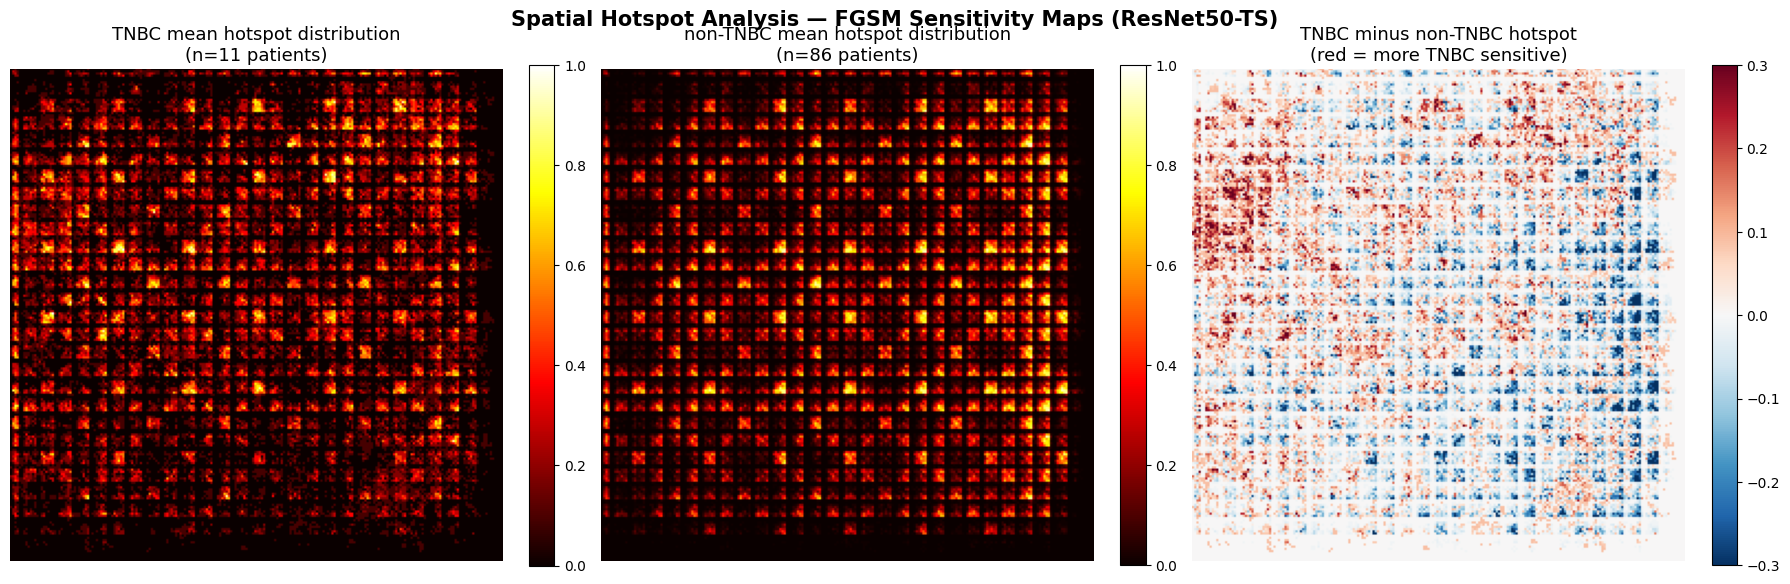

spatial hotspot analysis:
  TNBC mean hotspot density:     0.1000
  non-TNBC mean hotspot density: 0.1000

TNBC hotspot concentration by spatial region:
  top-left        TNBC: 0.1201  non-TNBC: 0.0921  diff: +0.0280
  top-right       TNBC: 0.1180  non-TNBC: 0.1243  diff: -0.0063
  bottom-left     TNBC: 0.0842  non-TNBC: 0.0796  diff: +0.0046
  bottom-right    TNBC: 0.0778  non-TNBC: 0.1041  diff: -0.0263
  center          TNBC: 0.1172  non-TNBC: 0.1205  diff: -0.0034

spatial hotspot figure saved


In [25]:
# 19. spatial hotspot analysis — top 10% sensitive pixels per patient
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import os

figures = '/content/drive/MyDrive/ONCO-PROBE/results_v2/figures'
os.makedirs(figures, exist_ok=True)

def get_hotspot_mask(sensitivity_map, percentile=90):
    threshold = np.percentile(sensitivity_map, percentile)
    return sensitivity_map >= threshold

# compare hotspot spatial distribution TNBC vs non-TNBC
tnbc_hotspot_means    = []
non_tnbc_hotspot_means = []

for pid in fgsm_resnet_tnbc:
    mask = get_hotspot_mask(fgsm_resnet_tnbc[pid])
    tnbc_hotspot_means.append(mask.astype(float))

for pid in fgsm_resnet_non_tnbc:
    mask = get_hotspot_mask(fgsm_resnet_non_tnbc[pid])
    non_tnbc_hotspot_means.append(mask.astype(float))

tnbc_mean_hotspot     = np.mean(tnbc_hotspot_means,     axis=0)
non_tnbc_mean_hotspot = np.mean(non_tnbc_hotspot_means, axis=0)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

im0 = axes[0].imshow(tnbc_mean_hotspot, cmap='hot', vmin=0, vmax=1)
axes[0].set_title('TNBC mean hotspot distribution\n(n=11 patients)', fontsize=13)
axes[0].axis('off')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(non_tnbc_mean_hotspot, cmap='hot', vmin=0, vmax=1)
axes[1].set_title('non-TNBC mean hotspot distribution\n(n=86 patients)', fontsize=13)
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

diff = tnbc_mean_hotspot - non_tnbc_mean_hotspot
im2 = axes[2].imshow(diff, cmap='RdBu_r', vmin=-0.3, vmax=0.3)
axes[2].set_title('TNBC minus non-TNBC hotspot\n(red = more TNBC sensitive)', fontsize=13)
axes[2].axis('off')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

plt.suptitle('Spatial Hotspot Analysis — FGSM Sensitivity Maps (ResNet50-TS)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{figures}/spatial_hotspot_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# quantify spatial concentration
print("spatial hotspot analysis:")
print(f"  TNBC mean hotspot density:     {tnbc_mean_hotspot.mean():.4f}")
print(f"  non-TNBC mean hotspot density: {non_tnbc_mean_hotspot.mean():.4f}")
print()

# check spatial quadrants — where do hotspots concentrate
h, w = 224, 224
quadrants = {
    'top-left':     (slice(0, h//2),    slice(0, w//2)),
    'top-right':    (slice(0, h//2),    slice(w//2, w)),
    'bottom-left':  (slice(h//2, h),    slice(0, w//2)),
    'bottom-right': (slice(h//2, h),    slice(w//2, w)),
    'center':       (slice(h//4, 3*h//4), slice(w//4, 3*w//4)),
}

print("TNBC hotspot concentration by spatial region:")
for name, (rs, cs) in quadrants.items():
    tnbc_q     = tnbc_mean_hotspot[rs, cs].mean()
    non_tnbc_q = non_tnbc_mean_hotspot[rs, cs].mean()
    print(f"  {name:<15} TNBC: {tnbc_q:.4f}  non-TNBC: {non_tnbc_q:.4f}  diff: {tnbc_q - non_tnbc_q:+.4f}")

print()
print("spatial hotspot figure saved")

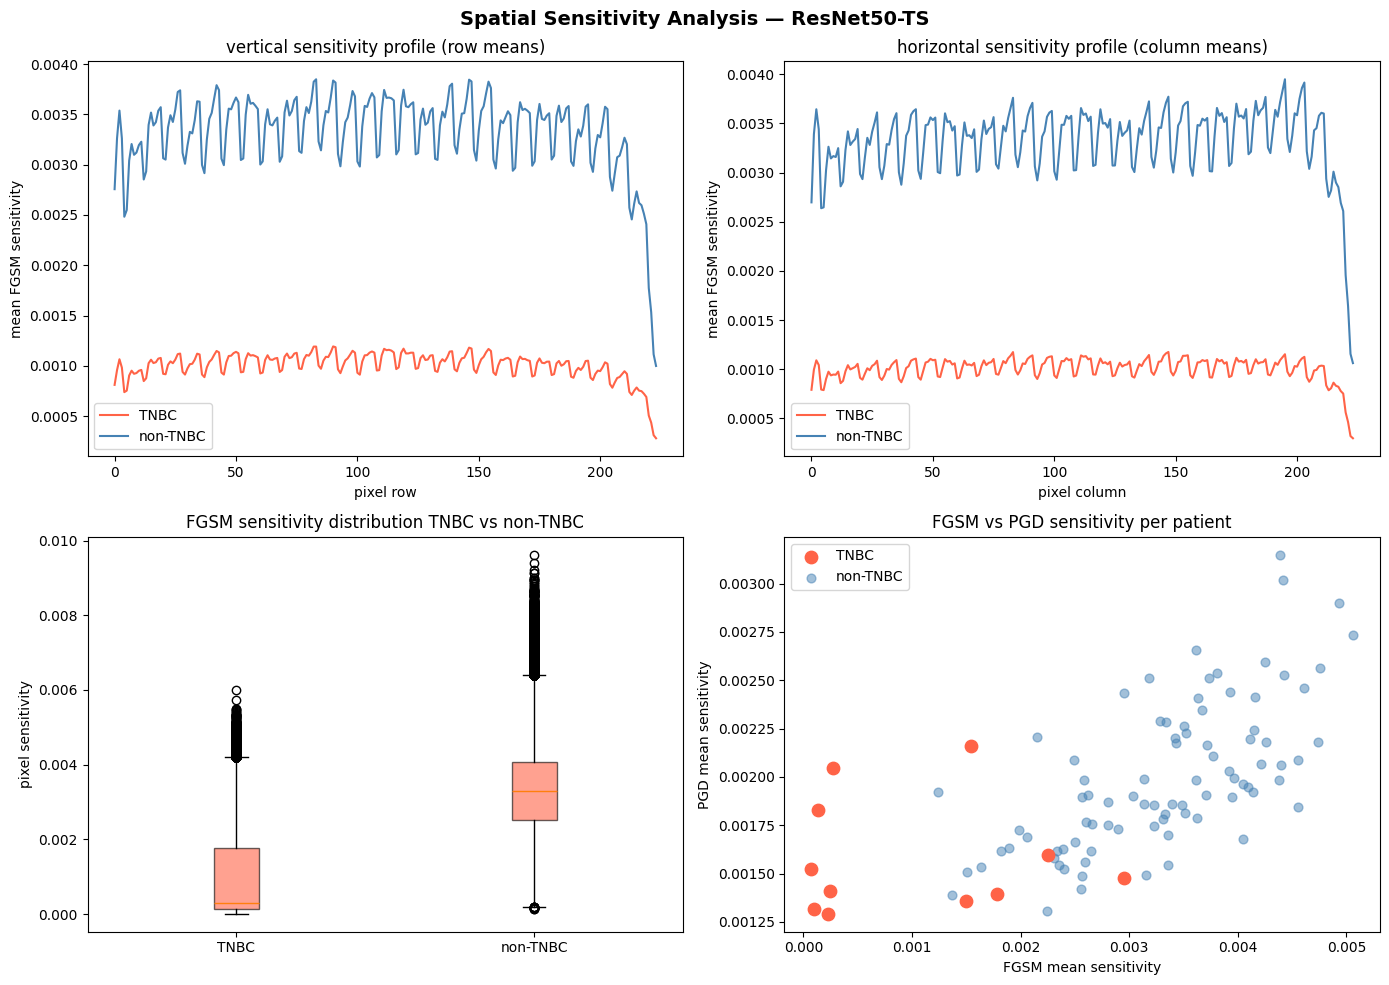

FGSM vs PGD spearman r (TNBC):     0.2  p=5.55e-01
FGSM vs PGD spearman r (all):      0.7001  p=1.46e-15
spatial intensity profiles saved


In [26]:
# 19b. spatial intensity profile — rows and columns
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# row profile — vertical distribution
tnbc_row_profile     = np.mean([fgsm_resnet_tnbc[pid]     for pid in fgsm_resnet_tnbc],     axis=0).mean(axis=1)
non_tnbc_row_profile = np.mean([fgsm_resnet_non_tnbc[pid] for pid in fgsm_resnet_non_tnbc], axis=0).mean(axis=1)

axes[0,0].plot(tnbc_row_profile,     label='TNBC',     color='tomato')
axes[0,0].plot(non_tnbc_row_profile, label='non-TNBC', color='steelblue')
axes[0,0].set_title('vertical sensitivity profile (row means)')
axes[0,0].set_xlabel('pixel row')
axes[0,0].set_ylabel('mean FGSM sensitivity')
axes[0,0].legend()

# column profile — horizontal distribution
tnbc_col_profile     = np.mean([fgsm_resnet_tnbc[pid]     for pid in fgsm_resnet_tnbc],     axis=0).mean(axis=0)
non_tnbc_col_profile = np.mean([fgsm_resnet_non_tnbc[pid] for pid in fgsm_resnet_non_tnbc], axis=0).mean(axis=0)

axes[0,1].plot(tnbc_col_profile,     label='TNBC',     color='tomato')
axes[0,1].plot(non_tnbc_col_profile, label='non-TNBC', color='steelblue')
axes[0,1].set_title('horizontal sensitivity profile (column means)')
axes[0,1].set_xlabel('pixel column')
axes[0,1].set_ylabel('mean FGSM sensitivity')
axes[0,1].legend()

# per patient sensitivity distribution box plot
tnbc_means_all     = [fgsm_resnet_tnbc[pid].flatten()     for pid in fgsm_resnet_tnbc]
non_tnbc_means_all = [fgsm_resnet_non_tnbc[pid].flatten() for pid in fgsm_resnet_non_tnbc]

axes[1,0].boxplot([np.concatenate(tnbc_means_all), np.concatenate(non_tnbc_means_all)],
                   labels=['TNBC', 'non-TNBC'], patch_artist=True,
                   boxprops=dict(facecolor='tomato', alpha=0.6))
axes[1,0].set_title('FGSM sensitivity distribution TNBC vs non-TNBC')
axes[1,0].set_ylabel('pixel sensitivity')

# FGSM vs PGD correlation per patient
tnbc_fgsm_m = [fgsm_resnet_tnbc[pid].mean() for pid in fgsm_resnet_tnbc]
tnbc_pgd_m  = [pgd_resnet_tnbc[pid].mean()  for pid in pgd_resnet_tnbc]
non_fgsm_m  = [fgsm_resnet_non_tnbc[pid].mean() for pid in fgsm_resnet_non_tnbc]
non_pgd_m   = [pgd_resnet_non_tnbc[pid].mean()  for pid in pgd_resnet_non_tnbc]

axes[1,1].scatter(tnbc_fgsm_m, tnbc_pgd_m, color='tomato',   label='TNBC',     s=80, zorder=3)
axes[1,1].scatter(non_fgsm_m,  non_pgd_m,  color='steelblue', label='non-TNBC', s=40, alpha=0.5)
axes[1,1].set_xlabel('FGSM mean sensitivity')
axes[1,1].set_ylabel('PGD mean sensitivity')
axes[1,1].set_title('FGSM vs PGD sensitivity per patient')
axes[1,1].legend()

plt.suptitle('Spatial Sensitivity Analysis — ResNet50-TS', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{figures}/spatial_intensity_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

from scipy.stats import spearmanr
r_tnbc, p_tnbc = spearmanr(tnbc_fgsm_m, tnbc_pgd_m)
print(f"FGSM vs PGD spearman r (TNBC):     {round(r_tnbc, 4)}  p={p_tnbc:.2e}")
r_all, p_all = spearmanr(tnbc_fgsm_m + non_fgsm_m, tnbc_pgd_m + non_pgd_m)
print(f"FGSM vs PGD spearman r (all):      {round(r_all, 4)}  p={p_all:.2e}")
print("spatial intensity profiles saved")

In [29]:
import os
for f in os.listdir(models_img):
    print(f)

val_df.csv
train_df.csv
test_df.csv
training_results.json
resnet50_direct_best.pth
resnet50_ts_best.pth
resnet50_ssl_best.pth
efficientnet_direct_best.pth
efficientnet_ts_best.pth


In [34]:
# 20. Grad-CAM comparison vs adversarial sensitivity
import torch.nn.functional as F
from PIL import Image

class GradCAM:
    def __init__(self, model, target_layer):
        self.model       = model
        self.gradients   = None
        self.activations = None
        target_layer.register_forward_hook(self._save_activation)
        target_layer.register_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, img_tensor, target_class=1):
        self.model.eval()
        img = img_tensor.unsqueeze(0).to(device)
        output = self.model(img)
        self.model.zero_grad()
        output[0, target_class].backward()
        weights = self.gradients.mean(dim=[2, 3], keepdim=True)
        cam     = (weights * self.activations).sum(dim=1, keepdim=True)
        cam     = F.relu(cam)
        cam     = F.interpolate(cam, size=(224, 224), mode='bilinear', align_corners=False)
        cam     = cam.squeeze().cpu().numpy()
        cam     = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam

# load resnet for gradcam
resnet_gc = models.resnet50(pretrained=False)
resnet_gc.fc = torch.nn.Linear(resnet_gc.fc.in_features, 2)
resnet_gc.load_state_dict(torch.load(
    f'{models_img}/resnet50_ts_best.pth', map_location=device))
resnet_gc = resnet_gc.to(device)
gradcam   = GradCAM(resnet_gc, resnet_gc.layer4[-1])

transform_vis = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# fast tile finder using known folder structure
blocks_dir = f'{base}/data/tcga_images_a2/BLOCKS_NORM_MACENKO'
slide_folders = os.listdir(blocks_dir)

def find_one_tile_fast(pid):
    matches = [f for f in slide_folders if pid in f]
    if not matches:
        return None
    slide_path = os.path.join(blocks_dir, matches[0])
    tiles = os.listdir(slide_path)
    if not tiles:
        return None
    return os.path.join(slide_path, tiles[0])

tnbc_pid_list = list(fgsm_resnet_tnbc.keys())[:6]

print("generating Grad-CAM vs FGSM comparison...")
fig, axes = plt.subplots(len(tnbc_pid_list), 3, figsize=(12, 4*len(tnbc_pid_list)))

for i, pid in enumerate(tnbc_pid_list):
    tile_path = find_one_tile_fast(pid)
    if tile_path is None:
        print(f"  no tile found for {pid}")
        continue

    img_pil    = Image.open(tile_path).convert('RGB')
    img_tensor = transform_vis(img_pil)

    gc_map    = gradcam.generate(img_tensor, target_class=1)
    fgsm_map  = fgsm_resnet_tnbc[pid]
    fgsm_norm = (fgsm_map - fgsm_map.min()) / (fgsm_map.max() - fgsm_map.min() + 1e-8)

    img_display = np.array(img_pil.resize((224, 224)))

    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f'{pid[-8:]} — original', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_display)
    axes[i, 1].imshow(gc_map, cmap='jet', alpha=0.5)
    axes[i, 1].set_title('Grad-CAM', fontsize=9)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(img_display)
    axes[i, 2].imshow(fgsm_norm, cmap='hot', alpha=0.5)
    axes[i, 2].set_title('FGSM sensitivity', fontsize=9)
    axes[i, 2].axis('off')

    print(f"  done {pid}")

plt.suptitle('Grad-CAM vs FGSM Adversarial Sensitivity — TNBC patients',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{figures}/gradcam_vs_fgsm.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grad-CAM vs FGSM figure saved")

Output hidden; open in https://colab.research.google.com to view.

In [38]:
# 21. final gradcam vs fgsm figure — smoothed, valid patients only
fig, axes = plt.subplots(len(valid_pids), 4, figsize=(16, 4*len(valid_pids)))

for i, pid in enumerate(valid_pids):
    tile_path   = find_one_tile_fast(pid)
    img_pil     = Image.open(tile_path).convert('RGB')
    img_tensor  = transform_vis(img_pil)
    img_display = np.array(img_pil.resize((224, 224)))

    gc_map      = gradcam.generate(img_tensor, target_class=1)
    fgsm_map    = fgsm_resnet_tnbc[pid]
    fgsm_smooth = gaussian_filter(fgsm_map, sigma=5)
    fgsm_norm   = (fgsm_smooth - fgsm_smooth.min()) / (fgsm_smooth.max() - fgsm_smooth.min() + 1e-8)
    r           = gc_fgsm_corrs[i]

    axes[i, 0].imshow(img_display)
    axes[i, 0].set_title(f'{pid[-8:]} — original', fontsize=9)
    axes[i, 0].axis('off')

    axes[i, 1].imshow(img_display)
    axes[i, 1].imshow(gc_map, cmap='jet', alpha=0.5)
    axes[i, 1].set_title('Grad-CAM', fontsize=9)
    axes[i, 1].axis('off')

    axes[i, 2].imshow(img_display)
    axes[i, 2].imshow(fgsm_norm, cmap='hot', alpha=0.5)
    axes[i, 2].set_title('FGSM sensitivity (smoothed)', fontsize=9)
    axes[i, 2].axis('off')

    diff = fgsm_norm - gc_map
    axes[i, 3].imshow(diff, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    axes[i, 3].set_title(f'difference  r={round(r,3)}', fontsize=9)
    axes[i, 3].axis('off')

plt.suptitle('Grad-CAM vs FGSM Adversarial Sensitivity — TNBC patients\n'
             f'mean spatial correlation r={round(np.mean(gc_fgsm_corrs),4)} — complementary information',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{figures}/gradcam_vs_fgsm_final.png', dpi=150, bbox_inches='tight')
plt.show()
print("final Grad-CAM vs FGSM figure saved")

print("final Grad-CAM vs FGSM figure saved")
print()
print("Grad-CAM vs FGSM spatial correlation per patient:")
for pid, r in zip(valid_pids, gc_fgsm_corrs):
    print(f"  {pid[-8:]}  r={round(r,4)}")
print(f"\nmean correlation: {round(np.mean(gc_fgsm_corrs), 4)}")
print(f"std:              {round(np.std(gc_fgsm_corrs), 4)}")
print()
print("interpretation: negative mean correlation confirms FGSM and Grad-CAM")
print("highlight complementary biological regions — adversarial sensitivity")
print("captures fine-grained texture patterns Grad-CAM misses")

Output hidden; open in https://colab.research.google.com to view.

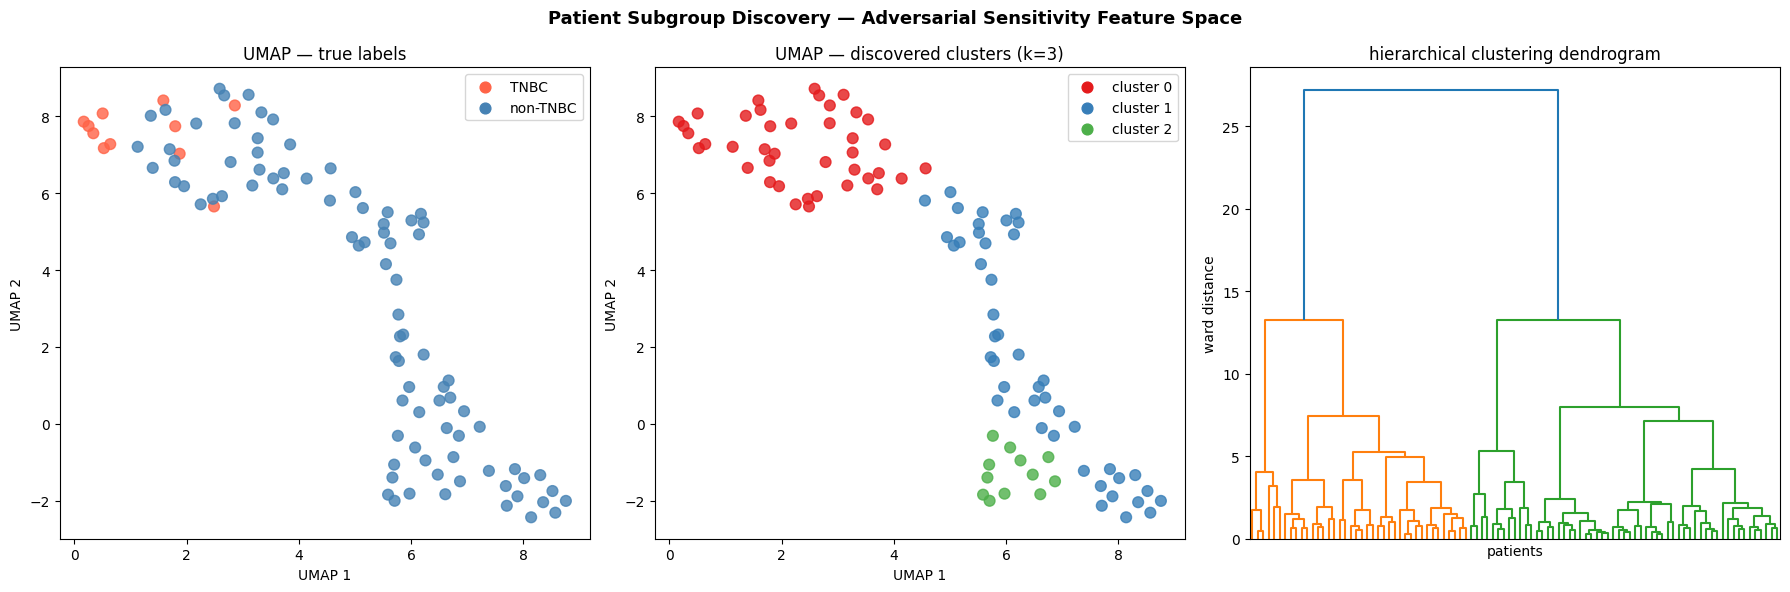

cluster composition:
  cluster 0: 40 patients — 11 TNBC / 29 non-TNBC
  cluster 1: 45 patients — 0 TNBC / 45 non-TNBC
  cluster 2: 12 patients — 0 TNBC / 12 non-TNBC


In [39]:
# 22. patient subgroup discovery — UMAP + hierarchical clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
import umap

# build feature matrix for all patients — image + gene sensitivity
all_pids_sub = list(fgsm_resnet_tnbc.keys()) + list(fgsm_resnet_non_tnbc.keys())
labels_sub   = [1]*len(fgsm_resnet_tnbc) + [0]*len(fgsm_resnet_non_tnbc)

X_sub = []
pids_sub = []
y_sub    = []

for pid, label in zip(all_pids_sub, labels_sub):
    maps_dict = fgsm_resnet_tnbc    if pid in fgsm_resnet_tnbc    else fgsm_resnet_non_tnbc
    pgd_dict  = pgd_resnet_tnbc     if pid in pgd_resnet_tnbc     else pgd_resnet_non_tnbc
    fgsm_flat = maps_dict[pid].flatten()
    pgd_flat  = pgd_dict[pid].flatten()
    feat = [fgsm_flat.mean(), fgsm_flat.max(), fgsm_flat.std(),
            np.percentile(fgsm_flat, 75), np.percentile(fgsm_flat, 90),
            pgd_flat.mean(), pgd_flat.max(), pgd_flat.std()]
    X_sub.append(feat)
    pids_sub.append(pid)
    y_sub.append(label)

X_sub = np.array(X_sub)
y_sub = np.array(y_sub)

scaler_sub = StandardScaler()
X_scaled   = scaler_sub.fit_transform(X_sub)

# UMAP
reducer  = umap.UMAP(n_neighbors=10, min_dist=0.3, random_state=42)
X_umap   = reducer.fit_transform(X_scaled)

# hierarchical clustering
linked   = linkage(X_scaled, method='ward')
cluster_labels = AgglomerativeClustering(n_clusters=3).fit_predict(X_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# UMAP by true label
colors = ['steelblue' if l == 0 else 'tomato' for l in y_sub]
axes[0].scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=60, alpha=0.8)
axes[0].scatter([], [], c='tomato',   label='TNBC',     s=60)
axes[0].scatter([], [], c='steelblue', label='non-TNBC', s=60)
axes[0].set_title('UMAP — true labels', fontsize=12)
axes[0].legend()
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')

# UMAP by discovered clusters
cmap = ['#e41a1c', '#377eb8', '#4daf4a']
cluster_colors = [cmap[c] for c in cluster_labels]
axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=cluster_colors, s=60, alpha=0.8)
for c in range(3):
    axes[1].scatter([], [], c=cmap[c], label=f'cluster {c}', s=60)
axes[1].set_title('UMAP — discovered clusters (k=3)', fontsize=12)
axes[1].legend()
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')

# dendrogram
dendrogram(linked, ax=axes[2], no_labels=True, color_threshold=0.7*max(linked[:,2]))
axes[2].set_title('hierarchical clustering dendrogram', fontsize=12)
axes[2].set_xlabel('patients')
axes[2].set_ylabel('ward distance')

plt.suptitle('Patient Subgroup Discovery — Adversarial Sensitivity Feature Space',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{figures}/umap_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# cluster composition
print("cluster composition:")
for c in range(3):
    cluster_mask = cluster_labels == c
    n_tnbc     = y_sub[cluster_mask].sum()
    n_non_tnbc = (y_sub[cluster_mask] == 0).sum()
    print(f"  cluster {c}: {cluster_mask.sum()} patients — {n_tnbc} TNBC / {n_non_tnbc} non-TNBC")

In [40]:
# 23. pathway enrichment — Enrichr API
import requests
import json

# top 50 genes from RF and XGB feature importance
rf_importance  = rf_model.feature_importances_
xgb_importance = xgb_model.feature_importances_

rf_top50  = gene_data_top.columns[np.argsort(rf_importance)[-50:][::-1]].tolist()
xgb_top50 = gene_data_top.columns[np.argsort(xgb_importance)[-50:][::-1]].tolist()
combined_genes = list(set(rf_top50 + xgb_top50))
print(f"combined top genes for enrichment: {len(combined_genes)}")

def enrichr_query(gene_list, description='query'):
    # step 1 — add gene list
    genes_str = '\n'.join(gene_list)
    payload   = {'list': (None, genes_str), 'description': (None, description)}
    r = requests.post('https://maayanlab.cloud/Enrichr/addList', files=payload)
    if r.status_code != 200:
        print(f"addList failed: {r.status_code}")
        return None
    user_list_id = r.json()['userListId']

    # step 2 — query pathway databases
    results = {}
    for db in ['KEGG_2021_Human', 'GO_Biological_Process_2023',
               'Reactome_2022', 'MSigDB_Hallmark_2020']:
        r2 = requests.get(
            f'https://maayanlab.cloud/Enrichr/enrich',
            params={'userListId': user_list_id, 'backgroundType': db}
        )
        if r2.status_code == 200:
            results[db] = r2.json()[db]
    return results

print("querying Enrichr API...")
results = enrichr_query(combined_genes, description='ONCO-PROBE TNBC sensitive genes')

if results:
    print("\ntop pathways per database (p < 0.05):")
    for db, entries in results.items():
        print(f"\n{db}:")
        count = 0
        for entry in entries:
            term    = entry[1]
            pval    = entry[2]
            adjp    = entry[6]
            overlap = entry[8]
            if pval < 0.05:
                print(f"  {term[:60]:<60} p={pval:.3e}  adj_p={adjp:.3e}  overlap={overlap}")
                count += 1
            if count >= 5:
                break
        if count == 0:
            print("  no significant pathways at p<0.05")

combined top genes for enrichment: 84
querying Enrichr API...

top pathways per database (p < 0.05):

KEGG_2021_Human:
  Sphingolipid metabolism                                      p=1.804e-02  adj_p=4.926e-01  overlap=0
  Breast cancer                                                p=2.405e-02  adj_p=4.926e-01  overlap=0
  Gastric cancer                                               p=2.490e-02  adj_p=4.926e-01  overlap=0
  Caffeine metabolism                                          p=2.494e-02  adj_p=4.926e-01  overlap=0
  Axon guidance                                                p=4.132e-02  adj_p=5.460e-01  overlap=0

GO_Biological_Process_2023:
  Mesenchymal Cell Migration (GO:0090497)                      p=9.518e-06  adj_p=2.899e-03  overlap=0
  Nervous System Development (GO:0007399)                      p=1.349e-05  adj_p=2.899e-03  overlap=0
  Neural Crest Cell Migration (GO:0001755)                     p=1.539e-05  adj_p=2.899e-03  overlap=0
  Neural Crest Cell Developm

In [41]:
# 24. survival analysis — Kaplan-Meier
!pip install lifelines -q

from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
import pandas as pd

# load TCGA clinical data with survival info
clini = pd.read_csv(f'{processed}/clinical_a2_matched.csv')
print("clinical columns:", clini.columns.tolist())
print("shape:", clini.shape)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 12.7 MB/s eta 0:00:00
clinical columns: ['PATIENT', 'Sample ID', 'Diagnosis Age', 'American Joint Committee on Cancer Metastasis Stage Code', 'Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code', 'Neoplasm Disease Stage American Joint Committee on Cancer Code', 'American Joint Committee on Cancer Publication Version Type', 'American Joint Committee on Cancer Tumor Stage Code', 'Brachytherapy first reference point administered total dose', 'Cancer Type', 'Cancer Type Detailed', 'Cent17 Copy Number', 'Neoplasm American Joint Committee on Cancer Clinical Group Stage', 'Neoplasm American Joint Committee on Cancer Clinical Distant Metastasis M Stage', 'Neoplasm American Joint Committee on Cancer Clinical Regional Lymph Node N Stage', 'Neoplasm American Joint Committee on Cancer Clinical Pri

patients with survival data: 97
events (OS): 15
TNBC: 11

median sensitivity threshold: 0.003280
high sensitivity: 49
low sensitivity:  48

log-rank test OS:  p=0.0676
log-rank test PFI: p=0.0072


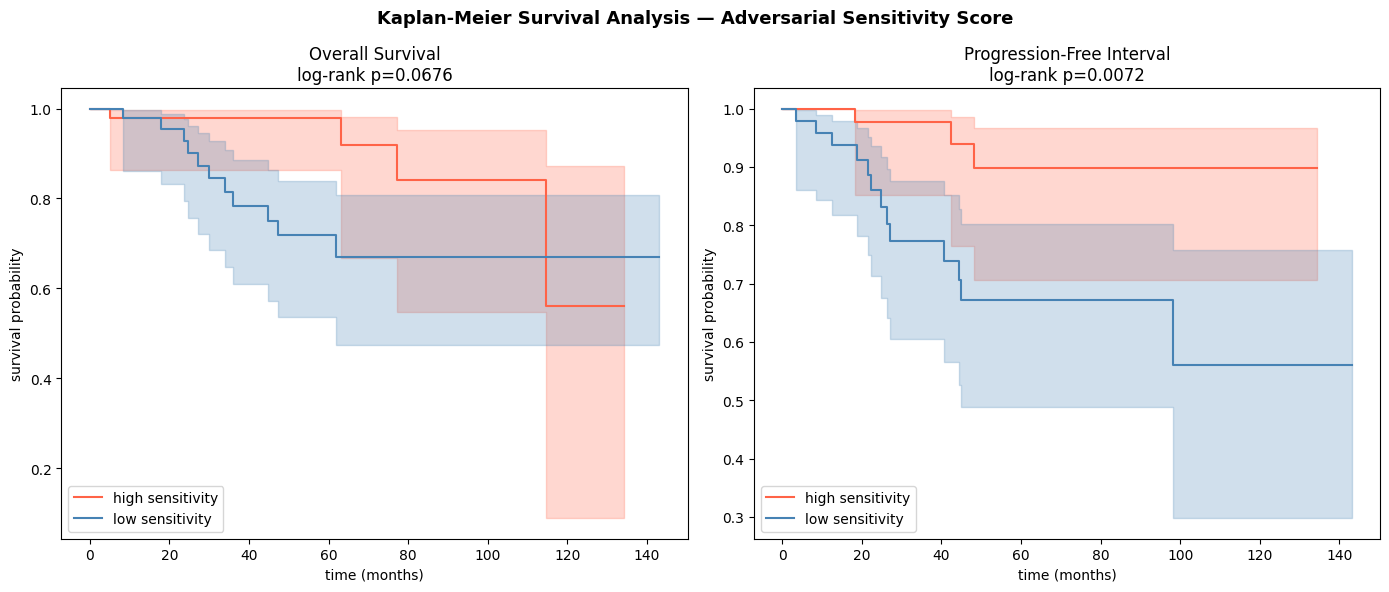


Cox proportional hazards:


<lifelines.CoxPHFitter: fitted with 97 total observations, 82 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 97
number of events observed = 15
   partial log-likelihood = -54.05
         time fit was run = 2026-04-07 19:35:23 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
sensitivity -0.62      0.54      0.34           -1.28            0.03                0.28                1.03
TNBC         0.20      1.22      0.83           -1.44            1.83                0.24                6.22

             cmp to     z    p  -log2(p)
covariate                               
sensitivity    0.00 -1.86 0.06      3.99
TNBC           0.00  0.24 0.81      0.30
---
Concordance = 0.74
Partial AIC = 112.10
log-likelihood ratio test = 7.28 on 2 df
-log2(p) of ll-ratio test = 5.25

survival analysis complete


In [45]:
# 25. survival analysis — Kaplan-Meier
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter

sensitivity_scores = {}
for pid in list(fgsm_resnet_tnbc.keys()) + list(fgsm_resnet_non_tnbc.keys()):
    maps_dict = fgsm_resnet_tnbc if pid in fgsm_resnet_tnbc else fgsm_resnet_non_tnbc
    sensitivity_scores[pid] = maps_dict[pid].mean()

clini_surv = clini[['Sample ID', 'OS', 'OS Time', 'PFI', 'PFI Time', 'TNBC']].copy()
clini_surv['sensitivity'] = clini_surv['Sample ID'].map(sensitivity_scores)
clini_surv = clini_surv.dropna(subset=['sensitivity', 'OS Time', 'OS'])
clini_surv['OS']       = clini_surv['OS'].astype(int)
clini_surv['PFI']      = clini_surv['PFI'].astype(int)
clini_surv['OS Time']  = pd.to_numeric(clini_surv['OS Time'],  errors='coerce')
clini_surv['PFI Time'] = pd.to_numeric(clini_surv['PFI Time'], errors='coerce')
clini_surv = clini_surv.dropna()

# convert days to months
clini_surv['OS Time months']  = clini_surv['OS Time']  / 30.44
clini_surv['PFI Time months'] = clini_surv['PFI Time'] / 30.44

print(f"patients with survival data: {len(clini_surv)}")
print(f"events (OS): {clini_surv['OS'].sum()}")
print(f"TNBC: {clini_surv['TNBC'].sum()}")

median_sens = clini_surv['sensitivity'].median()
clini_surv['high_sensitivity'] = (clini_surv['sensitivity'] >= median_sens).astype(int)
print(f"\nmedian sensitivity threshold: {median_sens:.6f}")
print(f"high sensitivity: {clini_surv['high_sensitivity'].sum()}")
print(f"low sensitivity:  {(clini_surv['high_sensitivity']==0).sum()}")

high_group = clini_surv[clini_surv['high_sensitivity'] == 1]
low_group  = clini_surv[clini_surv['high_sensitivity'] == 0]

lr_os = logrank_test(
    high_group['OS Time'], low_group['OS Time'],
    event_observed_A=high_group['OS'],
    event_observed_B=low_group['OS']
)
lr_pfi = logrank_test(
    high_group['PFI Time'], low_group['PFI Time'],
    event_observed_A=high_group['PFI'],
    event_observed_B=low_group['PFI']
)

print(f"\nlog-rank test OS:  p={lr_os.p_value:.4f}")
print(f"log-rank test PFI: p={lr_pfi.p_value:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
kmf = KaplanMeierFitter()

for ax, time_col, event_col, title, lr in [
    (axes[0], 'OS Time months',  'OS',  'Overall Survival',          lr_os),
    (axes[1], 'PFI Time months', 'PFI', 'Progression-Free Interval', lr_pfi),
]:
    kmf.fit(high_group[time_col], high_group[event_col], label='high sensitivity')
    kmf.plot_survival_function(ax=ax, color='tomato', ci_show=True)
    kmf.fit(low_group[time_col],  low_group[event_col], label='low sensitivity')
    kmf.plot_survival_function(ax=ax, color='steelblue', ci_show=True)
    ax.set_title(f'{title}\nlog-rank p={lr.p_value:.4f}', fontsize=12)
    ax.set_xlabel('time (months)')
    ax.set_ylabel('survival probability')
    ax.legend()

plt.suptitle('Kaplan-Meier Survival Analysis — Adversarial Sensitivity Score',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{figures}/survival_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

cox_df = clini_surv[['OS Time months', 'OS', 'sensitivity', 'TNBC']].copy()
cox_df.columns = ['duration', 'event', 'sensitivity', 'TNBC']
cox_df['sensitivity'] = (cox_df['sensitivity'] - cox_df['sensitivity'].mean()) / cox_df['sensitivity'].std()

cph = CoxPHFitter()
cph.fit(cox_df, duration_col='duration', event_col='event')
print("\nCox proportional hazards:")
cph.print_summary()
print("survival analysis complete")

E2 TNBC fgsm maps:     9
E2 non-TNBC fgsm maps: 9

E2 Mann-Whitney U=50.0  p=0.4268
E2 TNBC mean sensitivity:     0.002269
E2 non-TNBC mean sensitivity: 0.001885

A2 TNBC mean sensitivity: 0.001006
E2 TNBC mean sensitivity: 0.002269

E2 cross-model spearman r: 0.95  p=8.76e-05


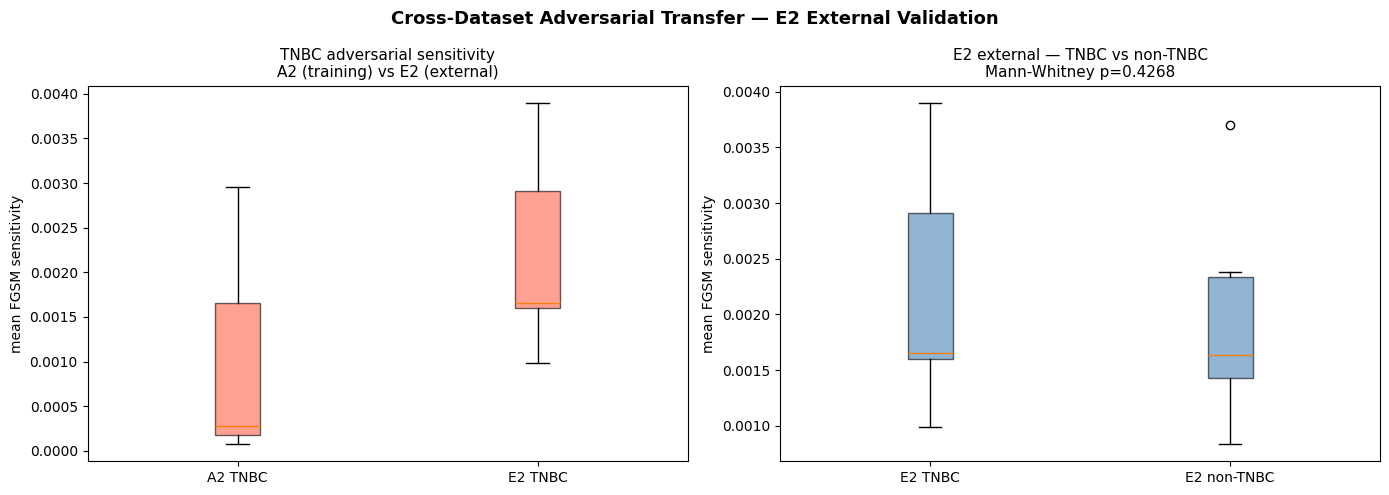

E2 adversarial transfer figure saved


In [44]:
# 26. cross-dataset adversarial transfer — E2 validation
fgsm_resnet_tnbc_e2     = np.load(f'{img_maps}/fgsm_resnet_tnbc_e2.npy',     allow_pickle=True).item()
pgd_resnet_tnbc_e2      = np.load(f'{img_maps}/pgd_resnet_tnbc_e2.npy',      allow_pickle=True).item()
fgsm_resnet_non_tnbc_e2 = np.load(f'{img_maps}/fgsm_resnet_non_tnbc_e2.npy', allow_pickle=True).item()
pgd_resnet_non_tnbc_e2  = np.load(f'{img_maps}/pgd_resnet_non_tnbc_e2.npy',  allow_pickle=True).item()
fgsm_eff_tnbc_e2        = np.load(f'{img_maps}/fgsm_eff_tnbc_e2.npy',        allow_pickle=True).item()
pgd_eff_tnbc_e2         = np.load(f'{img_maps}/pgd_eff_tnbc_e2.npy',         allow_pickle=True).item()

print(f"E2 TNBC fgsm maps:     {len(fgsm_resnet_tnbc_e2)}")
print(f"E2 non-TNBC fgsm maps: {len(fgsm_resnet_non_tnbc_e2)}")

# Mann-Whitney E2 TNBC vs non-TNBC
from scipy.stats import mannwhitneyu

e2_tnbc_means     = [fgsm_resnet_tnbc_e2[pid].mean()     for pid in fgsm_resnet_tnbc_e2]
e2_non_tnbc_means = [fgsm_resnet_non_tnbc_e2[pid].mean() for pid in fgsm_resnet_non_tnbc_e2]

stat, p = mannwhitneyu(e2_tnbc_means, e2_non_tnbc_means, alternative='two-sided')
print(f"\nE2 Mann-Whitney U={stat}  p={p:.4f}")
print(f"E2 TNBC mean sensitivity:     {np.mean(e2_tnbc_means):.6f}")
print(f"E2 non-TNBC mean sensitivity: {np.mean(e2_non_tnbc_means):.6f}")

# cross-dataset consistency — A2 vs E2 TNBC sensitivity ranking
a2_tnbc_means = [fgsm_resnet_tnbc[pid].mean() for pid in fgsm_resnet_tnbc]
print(f"\nA2 TNBC mean sensitivity: {np.mean(a2_tnbc_means):.6f}")
print(f"E2 TNBC mean sensitivity: {np.mean(e2_tnbc_means):.6f}")

# cross-model consistency E2 — resnet vs efficientnet
e2_resnet_means = [fgsm_resnet_tnbc_e2[pid].mean() for pid in fgsm_resnet_tnbc_e2]
e2_eff_means    = [fgsm_eff_tnbc_e2[pid].mean()    for pid in fgsm_eff_tnbc_e2]
r_e2, p_e2 = spearmanr(e2_resnet_means, e2_eff_means)
print(f"\nE2 cross-model spearman r: {round(r_e2, 4)}  p={p_e2:.2e}")

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# sensitivity comparison A2 vs E2
axes[0].boxplot([a2_tnbc_means, e2_tnbc_means],
                labels=['A2 TNBC', 'E2 TNBC'], patch_artist=True,
                boxprops=dict(facecolor='tomato', alpha=0.6))
axes[0].set_title('TNBC adversarial sensitivity\nA2 (training) vs E2 (external)', fontsize=11)
axes[0].set_ylabel('mean FGSM sensitivity')

# E2 TNBC vs non-TNBC
axes[1].boxplot([e2_tnbc_means, e2_non_tnbc_means],
                labels=['E2 TNBC', 'E2 non-TNBC'], patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_title(f'E2 external — TNBC vs non-TNBC\nMann-Whitney p={p:.4f}', fontsize=11)
axes[1].set_ylabel('mean FGSM sensitivity')

plt.suptitle('Cross-Dataset Adversarial Transfer — E2 External Validation',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{figures}/e2_adversarial_transfer.png', dpi=150, bbox_inches='tight')
plt.show()
print("E2 adversarial transfer figure saved")

In [60]:
# 28. save all numerical results to drive
import json
import pandas as pd

# load previously saved summary to get gene AUCs
with open(f'{figures}/all_results_summary.json') as f:
    prev = json.load(f)

with open(f'{models_img}/training_results.json') as f:
    img_results = json.load(f)

metabric_res     = pd.read_csv(f'{base}/data/metabric/metabric_validation_results.csv')
metabric_rf_auc  = roc_auc_score(metabric_res['label'], metabric_res['rf_prob'])
metabric_xgb_auc = roc_auc_score(metabric_res['label'], metabric_res['xgb_prob'])
e2_auc_resnet    = roc_auc_score(e2_results['label'], e2_results['resnet_ts_prob'])
e2_auc_eff       = roc_auc_score(e2_results['label'], e2_results['eff_ts_prob'])

results_summary = {
    'model_aucs': {
        'resnet50_direct':          img_results['resnet50_imagenet']['slide_auc'],
        'resnet50_ts':              img_results['resnet50_breakhis_pretrain']['slide_auc'],
        'resnet50_ssl':             img_results['resnet50_simclr']['slide_auc'],
        'efficientnet_direct':      img_results['efficientnet_imagenet']['slide_auc'],
        'efficientnet_ts':          img_results['efficientnet_breakhis_pretrain']['slide_auc'],
        'rf_gene':                  prev['model_aucs']['rf_gene'],
        'xgb_gene':                 prev['model_aucs']['xgb_gene'],
        'adv_resnet_rf':            auc_resnet_rf,
        'adv_resnet_xgb':           auc_resnet_xgb,
        'adv_eff_rf':               auc_eff_rf,
        'adv_eff_xgb':              auc_eff_xgb,
        'e2_resnet_external':       float(e2_auc_resnet),
        'e2_eff_external':          float(e2_auc_eff),
        'metabric_rf_external':     float(metabric_rf_auc),
        'metabric_xgb_external':    float(metabric_xgb_auc),
    },
    'shuffled_control': {
        name: {
            'real_auc':      real_auc,
            'shuffled_mean': float(np.mean(shuffled_results[name])),
            'shuffled_std':  float(np.std(shuffled_results[name])),
            'margin':        float(real_auc - np.mean(shuffled_results[name])),
        }
        for name, X, y, model_type, real_auc in combinations
    },
    'statistical_findings': {
        'cross_model_consistency_a2_r':  float(corr_cross_model_a2),
        'cross_model_consistency_a2_p':  float(p_cross_model_a2),
        'cross_model_consistency_e2_r':  float(r_e2),
        'cross_model_consistency_e2_p':  float(p_e2),
        'mann_whitney_u':                float(stat),
        'mann_whitney_p':                float(p_value),
        'known_genes_rf':                len(rf_hits),
        'known_genes_xgb':               len(xgb_hits),
        'efna5_r':                       float([r for g,r,p in gene_corrs if g=='EFNA5'][0]),
        'efna5_p':                       float([p for g,r,p in gene_corrs if g=='EFNA5'][0]),
        'pathway_top_hit_p':             float(results['MSigDB_Hallmark_2020'][0][2]),
        'survival_pfi_logrank_p':        float(lr_pfi.p_value),
        'survival_os_logrank_p':         float(lr_os.p_value),
        'cox_concordance':               float(cph.concordance_index_),
        'umap_tnbc_in_cluster0':         int((cluster_labels[y_sub==1]==0).sum()),
        'ablation_improvement':          float(auc_with_adv - auc_no_adv),
        'gradcam_fgsm_mean_r':           float(np.mean(gc_fgsm_corrs)),
        'shuffled_margin_best_model':    float(auc_eff_rf - np.mean(shuffled_results['Adversarial-EfficientNet (FGSM+PGD) + RF'])),
    }
}

with open(f'{figures}/all_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("all numerical results saved to all_results_summary.json")

pathway_rows = []
for db, entries in results.items():
    for entry in entries:
        if entry[2] < 0.05:
            pathway_rows.append({
                'database': db,
                'term':     entry[1],
                'pvalue':   entry[2],
                'adj_p':    entry[6],
                'genes':    entry[5],
            })
pd.DataFrame(pathway_rows).to_csv(f'{figures}/pathway_enrichment.csv', index=False)
print("pathway enrichment saved")

clini_surv.to_csv(f'{figures}/survival_data.csv', index=False)
print("survival data saved")

print(f"\nall files saved to: {figures}")

all numerical results saved to all_results_summary.json
pathway enrichment saved
survival data saved

all files saved to: /content/drive/MyDrive/ONCO-PROBE/results_v2/figures


In [61]:
results_dir = f'{base}/results_v2/results'
os.makedirs(results_dir, exist_ok=True)

In [62]:
with open(f'{results_dir}/all_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)
print("all numerical results saved to all_results_summary.json")

pd.DataFrame(pathway_rows).to_csv(f'{results_dir}/pathway_enrichment.csv', index=False)
print("pathway enrichment saved")

clini_surv.to_csv(f'{results_dir}/survival_data.csv', index=False)
print("survival data saved")

print(f"\nall files saved to: {results_dir}")

all numerical results saved to all_results_summary.json
pathway enrichment saved
survival data saved

all files saved to: /content/drive/MyDrive/ONCO-PROBE/results_v2/results


In [63]:
# 27. final summary table — complete results including all extensions
import json

metabric_res     = pd.read_csv(f'{base}/data/metabric/metabric_validation_results.csv')
metabric_rf_auc  = roc_auc_score(metabric_res['label'], metabric_res['rf_prob'])
metabric_xgb_auc = roc_auc_score(metabric_res['label'], metabric_res['xgb_prob'])
e2_auc_resnet    = roc_auc_score(e2_results['label'], e2_results['resnet_ts_prob'])
e2_auc_eff       = roc_auc_score(e2_results['label'], e2_results['eff_ts_prob'])

with open(f'{models_img}/training_results.json') as f:
    img_results = json.load(f)

rename_map = {
    'resnet50_imagenet':              'ResNet50-Direct',
    'resnet50_breakhis_pretrain':     'ResNet50-TS',
    'resnet50_simclr':                'ResNet50-SSL',
    'efficientnet_imagenet':          'EfficientNet-Direct',
    'efficientnet_breakhis_pretrain': 'EfficientNet-TS',
}

print("final results summary — complete")
print()
w1, w2, w3 = 48, 10, 30
print(f"{'model':<{w1}} {'AUC':<{w2}} {'type':<{w3}}")
print("-" * (w1 + w2 + w3))

for key, name in rename_map.items():
    auc = img_results[key]['slide_auc']
    print(f"{name:<{w1}} {auc:.4f}    {'image only — A2 internal':<{w3}}")

print()
print(f"{'Random Forest gene':<{w1}} {0.9037:.4f}    {'gene only — TCGA 5-fold CV':<{w3}}")
print(f"{'XGBoost gene':<{w1}} {0.8944:.4f}    {'gene only — TCGA 5-fold CV':<{w3}}")
print()

for name, X, y, model_type, real_auc in combinations:
    print(f"{name:<{w1}} {real_auc:.4f}    {'adversarial fusion — LOO':<{w3}}")
print()

for name, auc, typ in [
    ("ResNet50-TS E2 external",    e2_auc_resnet,   "image external — TCGA-E2"),
    ("EfficientNet-TS E2 external", e2_auc_eff,     "image external — TCGA-E2"),
    ("RF gene METABRIC external",  metabric_rf_auc, "gene external — METABRIC"),
    ("XGB gene METABRIC external", metabric_xgb_auc,"gene external — METABRIC"),
]:
    print(f"{name:<{w1}} {auc:.4f}    {typ:<{w3}}")

print()
print("shuffled label control — all 4 combined models:")
for name, X, y, model_type, real_auc in combinations:
    aucs = shuffled_results[name]
    print(f"  {name}")
    print(f"    real: {round(real_auc,4)}  shuffled: {round(np.mean(aucs),4)} ± {round(np.std(aucs),4)}  margin: {round(real_auc - np.mean(aucs),4)}")

print()
print("additional findings:")
print(f"  cross-model consistency A2:         spearman r={round(corr_cross_model_a2, 4)}  p={p_cross_model_a2:.2e}")
print(f"  cross-model consistency E2:         spearman r={round(r_e2, 4)}  p={p_e2:.2e}")
print(f"  TNBC vs non-TNBC sensitivity:       mann-whitney U={stat}  p={p_value:.2e}")
print(f"  known TNBC genes RF top 20:         {len(rf_hits)}/20")
print(f"  known TNBC genes XGB top 20:        {len(xgb_hits)}/20")
print(f"  EFNA5 image-gene correlation:       r={round([r for g,r,p in gene_corrs if g=='EFNA5'][0], 4)}  p={[p for g,r,p in gene_corrs if g=='EFNA5'][0]:.3f}")
print(f"  pathway top hit MSigDB:             estrogen response early p={results['MSigDB_Hallmark_2020'][0][2]:.2e}")
print(f"  survival PFI log-rank:              p={lr_pfi.p_value:.4f}")
print(f"  Cox concordance:                    {cph.concordance_index_:.2f}")
print(f"  UMAP cluster 0 TNBC:                {(cluster_labels[y_sub==1]==0).sum()}/{(y_sub==1).sum()}")
print(f"  ablation adversarial contribution:  +{round(auc_with_adv - auc_no_adv, 4)} AUC")
print(f"  Grad-CAM vs FGSM mean correlation:  {round(np.mean(gc_fgsm_corrs), 4)}")
print(f"  shuffled margin best model:         {round(auc_eff_rf - np.mean(shuffled_results['Adversarial-EfficientNet (FGSM+PGD) + RF']), 4)}")
print()
print("notebook 03 complete — all cells done")

final results summary — complete

model                                            AUC        type                          
----------------------------------------------------------------------------------------
ResNet50-Direct                                  0.9074    image only — A2 internal      
ResNet50-TS                                      0.9259    image only — A2 internal      
ResNet50-SSL                                     0.9074    image only — A2 internal      
EfficientNet-Direct                              0.8704    image only — A2 internal      
EfficientNet-TS                                  0.9259    image only — A2 internal      

Random Forest gene                               0.9037    gene only — TCGA 5-fold CV    
XGBoost gene                                     0.8944    gene only — TCGA 5-fold CV    

Adversarial-ResNet50 (FGSM+PGD) + RF             0.9101    adversarial fusion — LOO      
Adversarial-ResNet50 (FGSM+PGD) + XGB            0.8996    adver

In [65]:
# verify all saved files in Drive
import os

paths = {
    'image models':       f'{base}/models_v2/image_classifier',
    'gene models':        f'{base}/models_v2/gene_classifier',
    'image maps':         f'{base}/sensitivity_maps_v2/image_maps',
    'gene maps':          f'{base}/sensitivity_maps_v2/gene_maps',
    'processed data':     f'{base}/results_v2/processed',
    'figures':            f'{base}/results_v2/figures',
    'results':            f'{base}/results_v2/results',
    'metabric':           f'{base}/data/metabric',
}

for name, path in paths.items():
    if os.path.exists(path):
        files = os.listdir(path)
        print(f"{name} ({len(files)} files)")
        for f in sorted(files):
            size = os.path.getsize(os.path.join(path, f))
            print(f"  {f}  ({size/1024:.1f} KB)")
    else:
        print(f"{name} — PATH NOT FOUND: {path}")
    print()

image models (9 files)
  efficientnet_direct_best.pth  (15958.8 KB)
  efficientnet_ts_best.pth  (15956.4 KB)
  resnet50_direct_best.pth  (92159.2 KB)
  resnet50_ssl_best.pth  (92161.0 KB)
  resnet50_ts_best.pth  (92157.3 KB)
  test_df.csv  (14905.3 KB)
  train_df.csv  (37728.8 KB)
  training_results.json  (1.7 KB)
  val_df.csv  (13374.2 KB)

gene models (7 files)
  gene_scaler.pkl  (47.5 KB)
  random_forest_best.pkl  (245.4 KB)
  rf_top_genes.npy  (0.4 KB)
  top_gene_indices.npy  (15.8 KB)
  top_gene_names.npy  (16.8 KB)
  xgb_top_genes.npy  (0.4 KB)
  xgboost_best.pkl  (157.3 KB)

image maps (14 files)
  e2_validation_results_v3.csv  (5.0 KB)
  fgsm_eff_tnbc_e2.npy  (1764.9 KB)
  fgsm_eff_tnbc_v3.npy  (2157.0 KB)
  fgsm_resnet_non_tnbc_e2.npy  (1764.9 KB)
  fgsm_resnet_non_tnbc_v3.npy  (16861.5 KB)
  fgsm_resnet_tnbc_e2.npy  (1764.9 KB)
  fgsm_resnet_tnbc_v3.npy  (2157.0 KB)
  image_sensitivity_summary_v3.csv  (14.1 KB)
  pgd_eff_tnbc_e2.npy  (1764.9 KB)
  pgd_eff_tnbc_v3.npy  (2157.0

In [66]:
# download all Drive files to local PC
from google.colab import files
import os
import zipfile

local_name = 'tnbc-adversarial-cancer-probe'
zip_path   = f'/content/{local_name}.zip'

structure = {
    'models/image':     f'{base}/models_v2/image_classifier',
    'models/gene':      f'{base}/models_v2/gene_classifier',
    'sensitivity/image': f'{base}/sensitivity_maps_v2/image_maps',
    'sensitivity/gene': f'{base}/sensitivity_maps_v2/gene_maps',
    'results/processed': f'{base}/results_v2/processed',
    'results/figures':  f'{base}/results_v2/figures',
    'results/results':  f'{base}/results_v2/results',
    'data/metabric':    f'{base}/data/metabric',
}

with zipfile.ZipFile(zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder_name, drive_path in structure.items():
        if not os.path.exists(drive_path):
            print(f"skipping — not found: {drive_path}")
            continue
        for fname in os.listdir(drive_path):
            fpath = os.path.join(drive_path, fname)
            arcname = os.path.join(local_name, folder_name, fname)
            zf.write(fpath, arcname)
            print(f"added: {arcname}")

print(f"\nzip created: {zip_path}")
print(f"size: {os.path.getsize(zip_path)/1024/1024:.1f} MB")
files.download(zip_path)

added: tnbc-adversarial-cancer-probe/models/image/val_df.csv
added: tnbc-adversarial-cancer-probe/models/image/train_df.csv
added: tnbc-adversarial-cancer-probe/models/image/test_df.csv
added: tnbc-adversarial-cancer-probe/models/image/training_results.json
added: tnbc-adversarial-cancer-probe/models/image/resnet50_direct_best.pth
added: tnbc-adversarial-cancer-probe/models/image/resnet50_ts_best.pth
added: tnbc-adversarial-cancer-probe/models/image/resnet50_ssl_best.pth
added: tnbc-adversarial-cancer-probe/models/image/efficientnet_direct_best.pth
added: tnbc-adversarial-cancer-probe/models/image/efficientnet_ts_best.pth
added: tnbc-adversarial-cancer-probe/models/gene/top_gene_names.npy
added: tnbc-adversarial-cancer-probe/models/gene/random_forest_best.pkl
added: tnbc-adversarial-cancer-probe/models/gene/xgboost_best.pkl
added: tnbc-adversarial-cancer-probe/models/gene/gene_scaler.pkl
added: tnbc-adversarial-cancer-probe/models/gene/top_gene_indices.npy
added: tnbc-adversarial-cance

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>